In [12]:
# Cell 1: Imports & plotting settings
# (Chạy trong Jupyter notebook)
%matplotlib inline
import os
import re
import unicodedata
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


# Load dữ liệu


In [13]:
# Cell 2: Load dataframe và chuẩn hoá tên cột (snake_case không dấu)
PATH = "../../.././data_thuydien/dataCacDap/data_thuydien_Trị_An.csv"   # chỉnh đường dẫn nếu cần
df = pd.read_csv(PATH)
df.head()

,ten_ho,thoi_diem,muc_nuoc_thuong_luu_m,muc_nuoc_dang_binh_thuong_m,muc_nuoc_chet_m,luu_luong_den_ho_m3_s,tong_luong_xa_m3_s,tong_luong_xa_qua_dap_tran_m3_s,tong_luong_xa_qua_nha_may_m3_s,so_cua_xa_sau,so_cua_xa_mat
0,Trị An,2022-01-01 00:00:00,61.29,62,50,170.0,0.0,0.0,0.0,0,0
1,Trị An,2022-01-01 01:00:00,61.30,62,50,210.0,0.0,0.0,0.0,0,0
2,Trị An,2022-01-01 02:00:00,61.30,62,50,210.0,0.0,0.0,0.0,0,0
3,Trị An,2022-01-01 03:00:00,61.30,62,50,220.0,0.0,0.0,0.0,0,0
4,Trị An,2022-01-01 04:00:00,61.30,62,50,220.0,0.0,0.0,0.0,0,0


Xử lý tên tiếng việt


In [14]:
# Reload with utf-8-sig, normalize column names to snake_case (Vietnamese-aware), then parse thoi_diem
import pandas as pd, numpy as np, unicodedata, re, os
path = "../../.././data_thuydien/data_thuydien.csv"
df = pd.read_csv(path, dtype=str, encoding='utf-8-sig', low_memory=False)

# vn_to_snake (robust to leading/trailing spaces and BOM)
def vn_to_snake(s: str) -> str:
    s = str(s).strip()
    s_norm = unicodedata.normalize('NFD', s)
    s_no_accents = ''.join(ch for ch in s_norm if unicodedata.category(ch) != 'Mn')
    s_no_accents = s_no_accents.replace('đ', 'd').replace('Đ', 'D')
    s_snake = re.sub(r'[^a-zA-Z0-9]+', '_', s_no_accents).lower().strip('_')
    if re.match(r'^\d', s_snake or ''):
        s_snake = 'c_' + s_snake
    return s_snake or 'col'

orig_cols = list(df.columns)
new_cols = [vn_to_snake(c) for c in orig_cols]
col_map = dict(zip(orig_cols, new_cols))
df.rename(columns=col_map, inplace=True)
print("Renamed columns (sample):")
for o,n in list(col_map.items())[:10]:
    print(f"  {o!r} -> {n!r}")

# Which column corresponds to 'thoi_diem' after renaming?
print("\\nAll columns after rename (first 20):", list(df.columns)[:20])

# If thoi_diem exists, parse it using the robust parser from before
if 'thoi_diem' in df.columns:
    # preserve raw
    df['thoi_diem_raw'] = df['thoi_diem']
    # reuse previous parsing function (simpler)
    import unicodedata, re
    def _clean_vi_datetime(s):
        if pd.isna(s): return np.nan
        s = str(s).strip()
        if not s: return np.nan
        s = unicodedata.normalize('NFKC', s)
        s = s.replace('\u2013','-').replace('\u2014','-')
        s = re.sub(r'\s+', ' ', s)
        s = re.sub(r'\b(ict|gmt\+?7|utc\+?7|vn)\b', '', s, flags=re.I).strip()
        s = re.sub(r'(?i)\b(thg|thang|tháng)\s*(\d{1,2})\b', r'\2', s)
        s = re.sub(r'(?i)\bngay\b', '', s)
        s = re.sub(r'(?i)\bgio\b', ':', s)
        s = re.sub(r'(?i)\bphut\b', '', s)
        s = s.replace('h', ':')
        s = s.replace('.', '/').replace('-', '/')
        s = re.sub(r'(\d{1,2})\s*/\s*(\d{1,2})\s*/\s*(\d{2,4})', r'\1/\2/\3', s)
        s = re.sub(r'(\b\d{1,2})[:h](\d{1,2})([:](\d{1,2}))?', 
                   lambda m: f"{int(m.group(1)):02d}:{int(m.group(2)):02d}" + (f":{int(m.group(4)):02d}" if m.group(4) else ""), s)
        s = re.sub(r'\s+', ' ', s).strip()
        return s or np.nan
    def parse_series_vi_dt(series):
        cleaned = series.map(_clean_vi_datetime)
        dt = pd.to_datetime(cleaned, errors='coerce', dayfirst=True)
        mask_24 = cleaned.str.contains(r'\b24:00(?::00)?\b', na=False)
        if mask_24.any():
            fix24 = cleaned[mask_24].str.replace('24:00', '00:00', regex=False)
            dt.loc[mask_24] = pd.to_datetime(fix24, errors='coerce', dayfirst=True) + pd.Timedelta(days=1)
        # Excel / epoch / compact handled if needed (skipped for speed)
        return dt, cleaned
    dt, cleaned = parse_series_vi_dt(df['thoi_diem_raw'])
    df['thoi_diem_cleaned_txt'] = cleaned
    df['thoi_diem'] = dt
    # Summary and examples
    n = len(df)
    parsed = df['thoi_diem'].notna().sum()
    nat = n - parsed
    print(f"Rows: {n}, Parsed OK: {parsed}, NaT remaining: {nat}")
    # show head and problematic samples
    display(df.head(10))
    if nat>0:
        print("\\nCác mẫu còn NaT (tối đa 20):")
        display(df.loc[df['thoi_diem'].isna(), ['thoi_diem_raw','thoi_diem_cleaned_txt']].head(20))
    # Save cleaned file
    out_path = "../../.././data_thuydien/data_thuydien_noneVietnamese.csv"
    df.to_csv(out_path, index=False)
    print("\\nSaved cleaned CSV to:", out_path)
else:
    print("Sau khi rename, không tìm thấy cột 'thoi_diem'. Các cột hiện có:", list(df.columns)[:50])

df.head()

Renamed columns (sample):
  'Tên hồ' -> 'ten_ho'
  'Thời điểm' -> 'thoi_diem'
  'Mực nước  thượng lưu (m)' -> 'muc_nuoc_thuong_luu_m'
  'Mực nước  dâng bình thường (m)' -> 'muc_nuoc_dang_binh_thuong_m'
  'Mực nước  chết (m)' -> 'muc_nuoc_chet_m'
  'Lưu lượng  đến hồ  (m3/s)' -> 'luu_luong_den_ho_m3_s'
  'Tổng lượng xả  (m3/s)' -> 'tong_luong_xa_m3_s'
  'Tổng lượng xả  qua đập  tràn (m3/s)' -> 'tong_luong_xa_qua_dap_tran_m3_s'
  'Tổng lượng xả  qua nhà  máy (m3/s)' -> 'tong_luong_xa_qua_nha_may_m3_s'
  'Số cửa  xả sâu' -> 'so_cua_xa_sau'
\nAll columns after rename (first 20): ['ten_ho', 'thoi_diem', 'muc_nuoc_thuong_luu_m', 'muc_nuoc_dang_binh_thuong_m', 'muc_nuoc_chet_m', 'luu_luong_den_ho_m3_s', 'tong_luong_xa_m3_s', 'tong_luong_xa_qua_dap_tran_m3_s', 'tong_luong_xa_qua_nha_may_m3_s', 'so_cua_xa_sau', 'so_cua_xa_mat']
Rows: 103029, Parsed OK: 103029, NaT remaining: 0


,ten_ho,thoi_diem,muc_nuoc_thuong_luu_m,muc_nuoc_dang_binh_thuong_m,muc_nuoc_chet_m,luu_luong_den_ho_m3_s,tong_luong_xa_m3_s,tong_luong_xa_qua_dap_tran_m3_s,tong_luong_xa_qua_nha_may_m3_s,so_cua_xa_sau,so_cua_xa_mat,thoi_diem_raw,thoi_diem_cleaned_txt
0,Hòa Bình,2022-01-01 00:00:00,112.13,117,80,848,1104,0,1104,0,0,01/01/2022 00:00,01/01/2022 00:00
1,Sông Ba Hạ,2022-01-01 00:00:00,104.94,105,101,410,450,50,400,0,1,01/01/2022 00:00,01/01/2022 00:00
2,Trị An,2022-01-01 00:00:00,61.29,62,50,170,0,0,0,0,0,01/01/2022 00:00,01/01/2022 00:00
3,Hòa Bình,2022-01-01 01:00:00,112.14,117,80,700,589,0,589,0,0,01/01/2022 01:00,01/01/2022 01:00
4,Sông Ba Hạ,2022-01-01 01:00:00,104.93,105,101,405,450,50,400,0,1,01/01/2022 01:00,01/01/2022 01:00
5,Trị An,2022-01-01 01:00:00,61.3,62,50,210,0,0,0,0,0,01/01/2022 01:00,01/01/2022 01:00
6,Hòa Bình,2022-01-01 02:00:00,112.14,117,80,700,589,0,589,0,0,01/01/2022 02:00,01/01/2022 02:00
7,Sông Ba Hạ,2022-01-01 02:00:00,104.93,105,101,415,450,50,400,0,1,01/01/2022 02:00,01/01/2022 02:00
8,Trị An,2022-01-01 02:00:00,61.3,62,50,210,0,0,0,0,0,01/01/2022 02:00,01/01/2022 02:00
9,Hòa Bình,2022-01-01 03:00:00,112.14,117,80,700,589,0,589,0,0,01/01/2022 03:00,01/01/2022 03:00


\nSaved cleaned CSV to: ../../.././data_thuydien/data_thuydien_noneVietnamese.csv


,ten_ho,thoi_diem,muc_nuoc_thuong_luu_m,muc_nuoc_dang_binh_thuong_m,muc_nuoc_chet_m,luu_luong_den_ho_m3_s,tong_luong_xa_m3_s,tong_luong_xa_qua_dap_tran_m3_s,tong_luong_xa_qua_nha_may_m3_s,so_cua_xa_sau,so_cua_xa_mat,thoi_diem_raw,thoi_diem_cleaned_txt
0,Hòa Bình,2022-01-01 00:00:00,112.13,117,80,848,1104,0,1104,0,0,01/01/2022 00:00,01/01/2022 00:00
1,Sông Ba Hạ,2022-01-01 00:00:00,104.94,105,101,410,450,50,400,0,1,01/01/2022 00:00,01/01/2022 00:00
2,Trị An,2022-01-01 00:00:00,61.29,62,50,170,0,0,0,0,0,01/01/2022 00:00,01/01/2022 00:00
3,Hòa Bình,2022-01-01 01:00:00,112.14,117,80,700,589,0,589,0,0,01/01/2022 01:00,01/01/2022 01:00
4,Sông Ba Hạ,2022-01-01 01:00:00,104.93,105,101,405,450,50,400,0,1,01/01/2022 01:00,01/01/2022 01:00


In [15]:
df = df.drop(columns=['thoi_diem_raw', 'thoi_diem_cleaned_txt'], errors='ignore')
df.to_csv(out_path, index=False)

# Thống kê đơn biến


In [16]:
# Tạo bảng thống kê mở rộng cho các cột numeric được chỉ định và hiển thị kết quả.
import pandas as pd, numpy as np
path = "../../.././data_thuydien/dataCacDap/data_thuydien_Trị_An.csv"
df = pd.read_csv(path, low_memory=False)

cols_target = [
    "muc_nuoc_thuong_luu_m",
    "luu_luong_den_ho_m3_s",
    "tong_luong_xa_m3_s",
    "tong_luong_xa_qua_dap_tran_m3_s",
    "tong_luong_xa_qua_nha_may_m3_s"    
]

# Kiểm tra tồn tại cột
missing_cols = [c for c in cols_target if c not in df.columns]
if missing_cols:
    raise KeyError(f"Các cột sau không tồn tại trong file: {missing_cols}")

# Chuyển sang numeric (nếu có chuỗi), giữ bản gốc để truy vết
df_num = df[cols_target].apply(pd.to_numeric, errors='coerce')

def extended_stats(series: pd.Series):
    s = series.dropna()
    vc = s.value_counts()
    top = vc.index[0] if not vc.empty else np.nan
    freq = int(vc.iloc[0]) if not vc.empty else 0
    return {
        'count': int(series.count()),
        'missing': int(series.isna().sum()),
        'unique': int(series.nunique(dropna=True)),
        'top': top,
        'freq': freq,
        'mean': float(series.mean()) if series.count()>0 else np.nan,
        'std': float(series.std(ddof=1)) if series.count()>1 else np.nan,
        'min': float(series.min()) if series.count()>0 else np.nan,
        '25%': float(series.quantile(0.25)) if series.count()>0 else np.nan,
        '50%': float(series.quantile(0.5)) if series.count()>0 else np.nan,
        '75%': float(series.quantile(0.75)) if series.count()>0 else np.nan,
        'max': float(series.max()) if series.count()>0 else np.nan,
        'skew': float(series.skew()) if series.count()>2 else np.nan,
        'kurtosis': float(series.kurt()) if series.count()>3 else np.nan
    }

rows = {c: extended_stats(df_num[c]) for c in cols_target}
summary_df = pd.DataFrame.from_dict(rows, orient='index')[
    ['count','missing','unique','top','freq','mean','std','min','25%','50%','75%','max','skew','kurtosis']
]

# Hiển thị cả describe() mặc định để so sánh
display("Pandas describe() (numeric):")
display(df_num.describe().T)

display("Bảng thống kê mở rộng (bao gồm top/freq):")
display(summary_df)

# Lưu ra CSV tạm nếu người dùng muốn tải
out_path = ".././ThongKeDonBien/TriAn/numeric_stats_extended.csv"
summary_df.to_csv(out_path)
print("Saved extended stats to:", out_path)



'Pandas describe() (numeric):'

,count,mean,std,min,25%,50%,75%,max
muc_nuoc_thuong_luu_m,34343.0,67.287781,732.745553,6.42,55.71,59.35,61.42,61324.0
luu_luong_den_ho_m3_s,34343.0,495.420464,436.154677,0.00,150.00,330.00,780.00,2940.0
tong_luong_xa_m3_s,34343.0,498.515214,420.591535,0.00,0.00,550.00,850.00,2090.0
tong_luong_xa_qua_dap_tran_m3_s,34331.0,36.872098,138.566335,0.00,0.00,0.00,0.00,1140.0
tong_luong_xa_qua_nha_may_m3_s,34342.0,461.669443,366.925119,0.00,0.00,550.00,826.00,980.0


'Bảng thống kê mở rộng (bao gồm top/freq):'

,count,missing,unique,top,freq,mean,std,min,25%,50%,75%,max,skew,kurtosis
muc_nuoc_thuong_luu_m,34343,0,1161,61.42,276,67.287781,732.745553,6.42,55.71,59.35,61.42,61324.0,82.866970,6865.867087
luu_luong_den_ho_m3_s,34343,0,270,90.00,1143,495.420464,436.154677,0.00,150.00,330.00,780.00,2940.0,1.219722,1.321510
tong_luong_xa_m3_s,34343,0,803,0.00,10801,498.515214,420.591535,0.00,0.00,550.00,850.00,2090.0,0.238925,-0.717725
tong_luong_xa_qua_dap_tran_m3_s,34331,12,32,0.00,30880,36.872098,138.566335,0.00,0.00,0.00,0.00,1140.0,4.685419,23.417976
tong_luong_xa_qua_nha_may_m3_s,34342,1,587,0.00,10802,461.669443,366.925119,0.00,0.00,550.00,826.00,980.0,-0.186903,-1.673979


Saved extended stats to: .././ThongKeDonBien/TriAn/numeric_stats_extended.csv


# Trực quan hoá đơn biến


In [17]:
# Cell 3: Danh sách biến liên tục cần phân tích và chuyển về numeric an toàn
cols_target = [
    "muc_nuoc_thuong_luu_m",
    "luu_luong_den_ho_m3_s",
    "tong_luong_xa_m3_s",
    "tong_luong_xa_qua_dap_tran_m3_s",
    "tong_luong_xa_qua_nha_may_m3_s"    
]

present = [c for c in cols_target if c in df.columns]
missing = [c for c in cols_target if c not in df.columns]
print("Có trong dataset:", present)
if missing:
    print("Không tìm thấy (bỏ qua):", missing)

out_dir = ".././TrucQuanDonBien/TriAn"

Có trong dataset: ['muc_nuoc_thuong_luu_m', 'luu_luong_den_ho_m3_s', 'tong_luong_xa_m3_s', 'tong_luong_xa_qua_dap_tran_m3_s', 'tong_luong_xa_qua_nha_may_m3_s']


muc_nuoc_thuong_luu_m IQR bounds: LB=47.14, UB=69.98
Full n=34,343 | Inlier n=34,334 | Outlier n=9


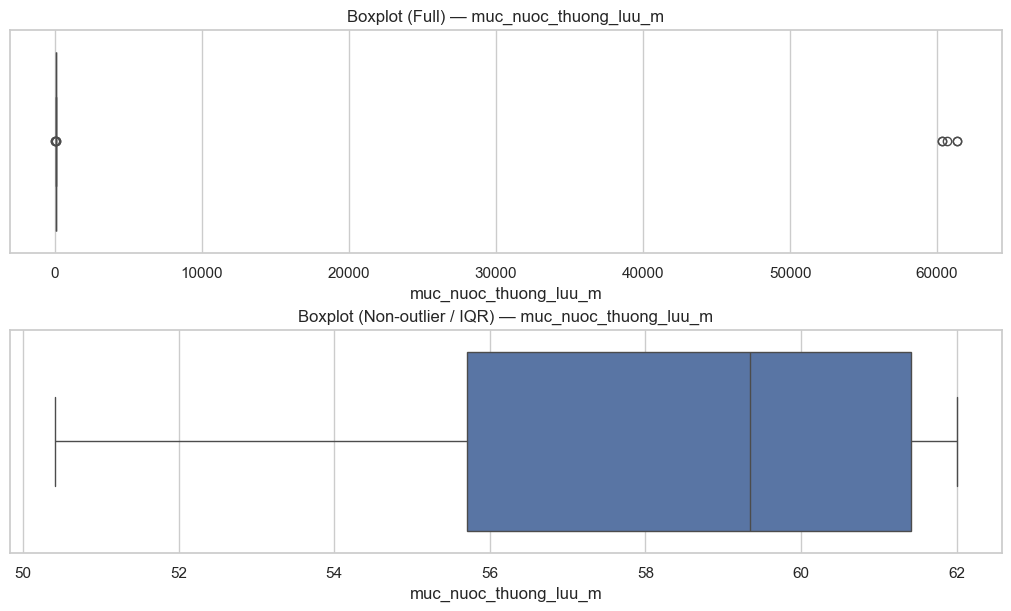

Saved: .././TrucQuanDonBien/TriAn\muc_nuoc_thuong_luu_m_boxplot_full_and_inlier.png


In [18]:
c = "muc_nuoc_thuong_luu_m"
s = df[c].dropna().astype(float)

if s.empty:
    print(f"{c}: không có dữ liệu sau khi clean. Bỏ qua.")
else:
    # Output folder
    out_dir = out_dir if 'out_dir' in globals() else ".././TrucQuanDonBien/SongBaHa"
    os.makedirs(out_dir, exist_ok=True)

    # --- IQR bounds ---
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1

    LB = Q1 - 1.5 * IQR
    UB = Q3 + 1.5 * IQR

    # Non-outlier series
    s_inlier = s[(s >= LB) & (s <= UB)]

    print(f"{c} IQR bounds: LB={LB:.2f}, UB={UB:.2f}")
    print(f"Full n={len(s):,} | Inlier n={len(s_inlier):,} | Outlier n={(len(s)-len(s_inlier)):,}")

    # --- Plot ---
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)

    # Boxplot (full)
    sns.boxplot(x=s, ax=axes[0])
    axes[0].set_title(f"Boxplot (Full) — {c}")
    axes[0].set_xlabel(c)

    # Boxplot (non-outlier)
    sns.boxplot(x=s_inlier, ax=axes[1])
    axes[1].set_title(f"Boxplot (Non-outlier / IQR) — {c}")
    axes[1].set_xlabel(c)

    # Save & show
    fn = os.path.join(out_dir, f"{c}_boxplot_full_and_inlier.png")
    fig.savefig(fn, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)

    print(f"Saved: {fn}")

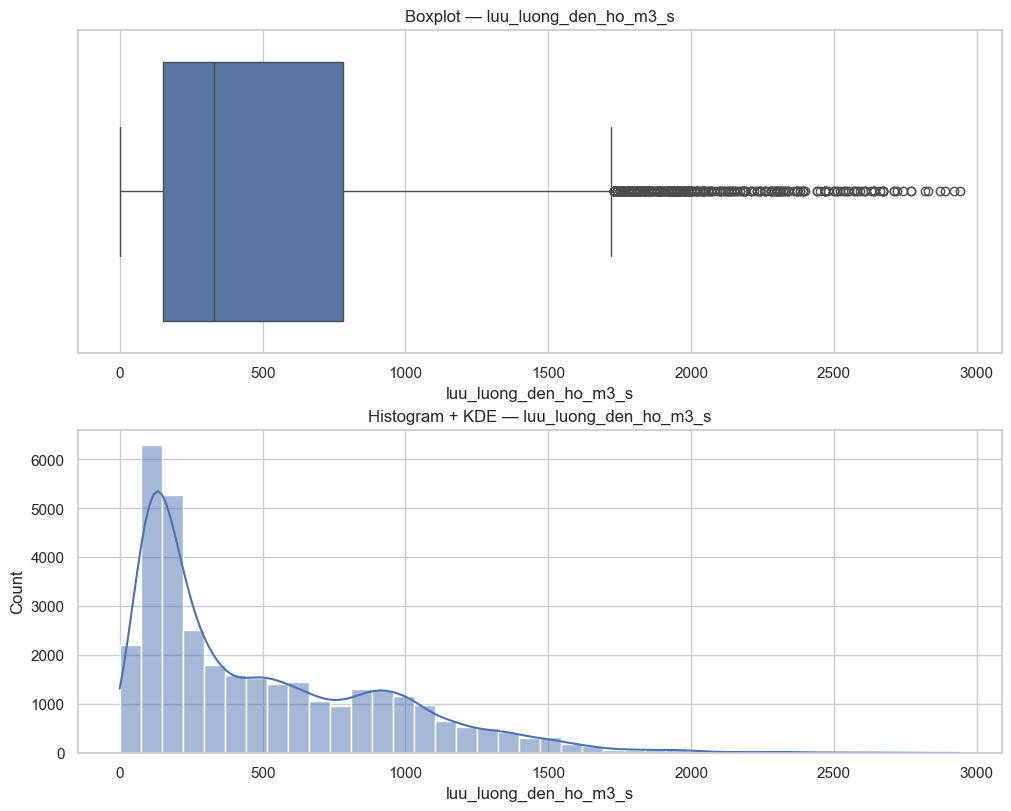

Saved: .././TrucQuanDonBien/TriAn\luu_luong_den_ho_m3_s_box_hist.png


In [19]:
c = "luu_luong_den_ho_m3_s"
s = df[c].dropna().astype(float)

if s.empty:
    print(f"{c}: không có dữ liệu sau khi clean. Bỏ qua.")
else:
    out_dir = out_dir if 'out_dir' in globals() else ".././TrucQuanDonBien/TriAn"
    os.makedirs(out_dir, exist_ok=True)

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True)

    # Boxplot (hàng trên)
    sns.boxplot(x=s, ax=axes[0])
    axes[0].set_title(f"Boxplot — {c}")
    axes[0].set_xlabel(c)

    # Histogram + KDE (hàng dưới)
    sns.histplot(s, bins=40, kde=True, ax=axes[1])
    axes[1].set_title(f"Histogram + KDE — {c}")
    axes[1].set_xlabel(c)
    axes[1].set_ylabel("Count")

    # Lưu và hiển thị
    fn = os.path.join(out_dir, f"{c}_box_hist.png")
    fig.savefig(fn, bbox_inches='tight', dpi=150)
    plt.show()
    plt.close(fig)

    print(f"Saved: {fn}")

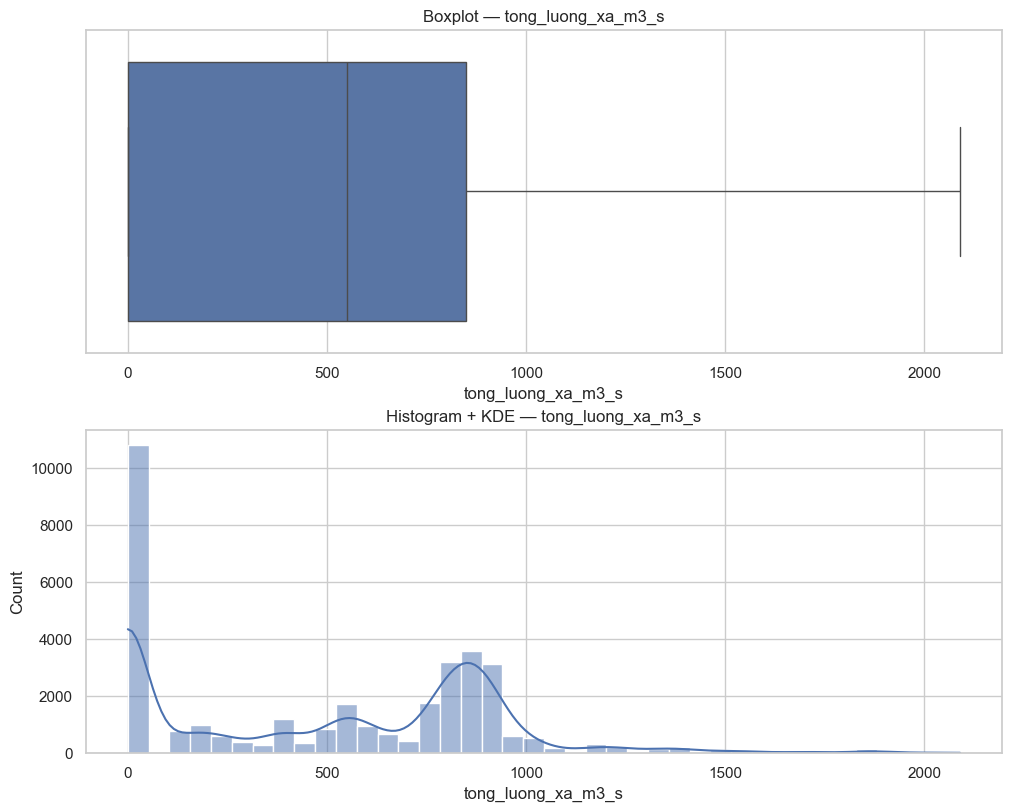

Saved: .././TrucQuanDonBien/TriAn\tong_luong_xa_m3_s_box_hist.png


In [20]:
c = "tong_luong_xa_m3_s"
s = df[c].dropna().astype(float)

if s.empty:
    print(f"{c}: không có dữ liệu sau khi clean. Bỏ qua.")
else:
    out_dir = out_dir if 'out_dir' in globals() else ".././TrucQuanDonBien/TriAn"
    os.makedirs(out_dir, exist_ok=True)

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True)

    # Boxplot (hàng trên)
    sns.boxplot(x=s, ax=axes[0])
    axes[0].set_title(f"Boxplot — {c}")
    axes[0].set_xlabel(c)

    # Histogram + KDE (hàng dưới)
    sns.histplot(s, bins=40, kde=True, ax=axes[1])
    axes[1].set_title(f"Histogram + KDE — {c}")
    axes[1].set_xlabel(c)
    axes[1].set_ylabel("Count")

    # Lưu và hiển thị
    fn = os.path.join(out_dir, f"{c}_box_hist.png")
    fig.savefig(fn, bbox_inches='tight', dpi=150)
    plt.show()
    plt.close(fig)

    print(f"Saved: {fn}")

"tong_luong_xa_qua_dap_tran_m3_s",
    "tong_luong_xa_qua_nha_may_m3_s"  

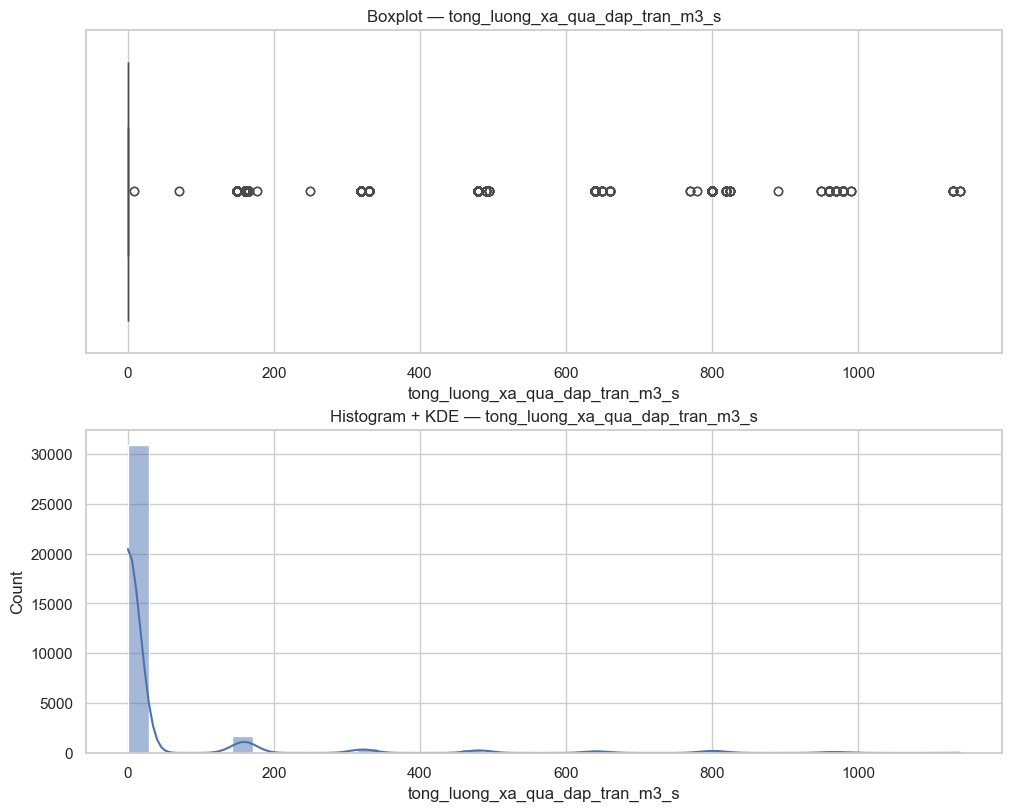

Saved: .././TrucQuanDonBien/TriAn\tong_luong_xa_qua_dap_tran_m3_s_box_hist.png


In [21]:
c = "tong_luong_xa_qua_dap_tran_m3_s"
s = df[c].dropna().astype(float)

if s.empty:
    print(f"{c}: không có dữ liệu sau khi clean. Bỏ qua.")
else:
    out_dir = out_dir if 'out_dir' in globals() else ".././TrucQuanDonBien/TriAn"
    os.makedirs(out_dir, exist_ok=True)

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True)

    # Boxplot (hàng trên)
    sns.boxplot(x=s, ax=axes[0])
    axes[0].set_title(f"Boxplot — {c}")
    axes[0].set_xlabel(c)

    # Histogram + KDE (hàng dưới)
    sns.histplot(s, bins=40, kde=True, ax=axes[1])
    axes[1].set_title(f"Histogram + KDE — {c}")
    axes[1].set_xlabel(c)
    axes[1].set_ylabel("Count")

    # Lưu và hiển thị
    fn = os.path.join(out_dir, f"{c}_box_hist.png")
    fig.savefig(fn, bbox_inches='tight', dpi=150)
    plt.show()
    plt.close(fig)

    print(f"Saved: {fn}")

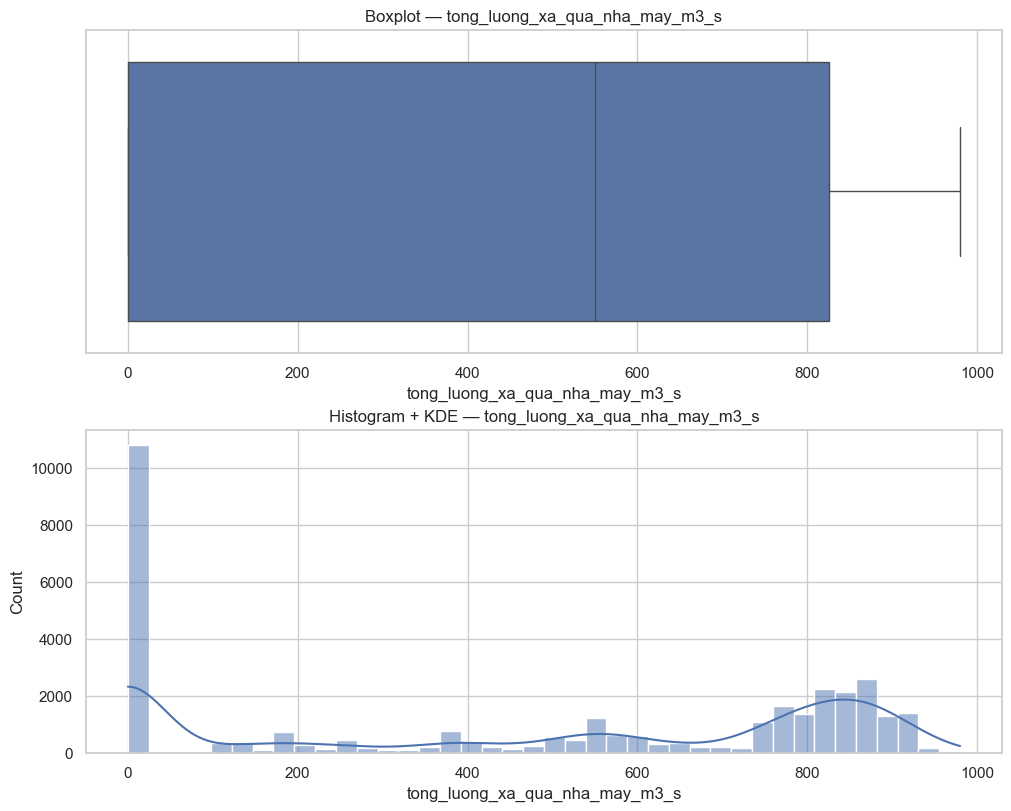

Saved: .././TrucQuanDonBien/TriAn\tong_luong_xa_qua_nha_may_m3_s_box_hist.png


In [22]:
c = "tong_luong_xa_qua_nha_may_m3_s"
s = df[c].dropna().astype(float)

if s.empty:
    print(f"{c}: không có dữ liệu sau khi clean. Bỏ qua.")
else:
    out_dir = out_dir if 'out_dir' in globals() else ".././TrucQuanDonBien/TriAn"
    os.makedirs(out_dir, exist_ok=True)

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True)

    # Boxplot (hàng trên)
    sns.boxplot(x=s, ax=axes[0])
    axes[0].set_title(f"Boxplot — {c}")
    axes[0].set_xlabel(c)

    # Histogram + KDE (hàng dưới)
    sns.histplot(s, bins=40, kde=True, ax=axes[1])
    axes[1].set_title(f"Histogram + KDE — {c}")
    axes[1].set_xlabel(c)
    axes[1].set_ylabel("Count")

    # Lưu và hiển thị
    fn = os.path.join(out_dir, f"{c}_box_hist.png")
    fig.savefig(fn, bbox_inches='tight', dpi=150)
    plt.show()
    plt.close(fig)

    print(f"Saved: {fn}")

# Trực quan đa biến


## Cái này thiên hướng thống kê


('.././TrucQuanDaBien/TriAn\\pairplot_sample.png',
 '.././TrucQuanDaBien/TriAn\\correlation_heatmap.png')

<Figure size 1200x1200 with 0 Axes>

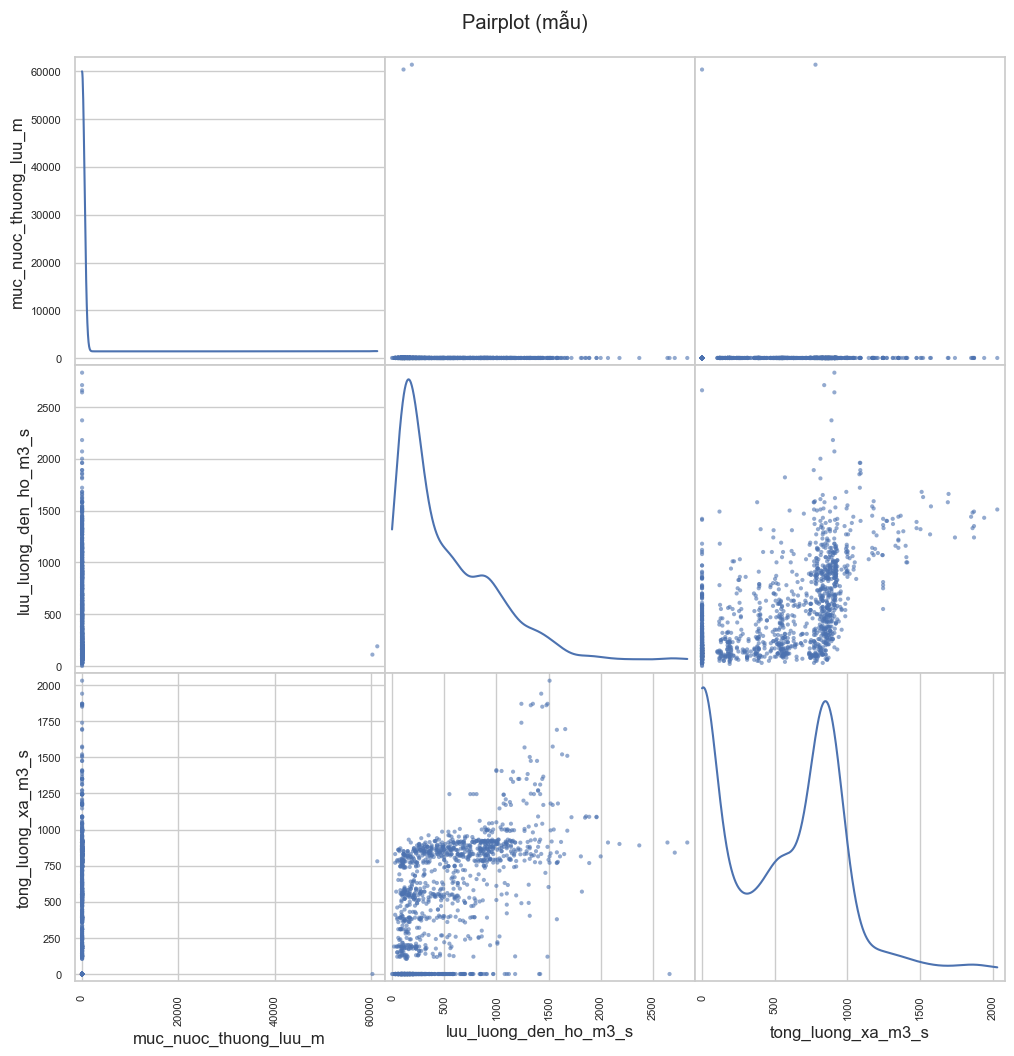

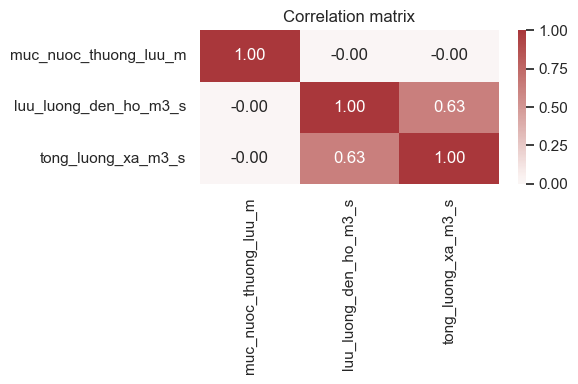

In [23]:
# Create and save pairplot equivalent using pandas.scatter_matrix and correlation heatmap
import os, re, unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns

OUT_DIR = ".././TrucQuanDaBien/TriAn"
os.makedirs(OUT_DIR, exist_ok=True)

paths = ["../../.././data_thuydien/dataCacDap/data_thuydien_Trị_An.csv"]
df = None
for p in paths:
    try:
        df = pd.read_csv(p)
        break
    except Exception:
        df = None

if df is None:
    raise FileNotFoundError("Không tìm thấy file dữ liệu.")

def vn_to_snake(s: str) -> str:
    s = str(s).strip()
    s_norm = unicodedata.normalize('NFD', s)
    s_no_accents = ''.join(ch for ch in s_norm if unicodedata.category(ch) != 'Mn')
    s_no_accents = s_no_accents.replace('đ', 'd').replace('Đ', 'D')
    s_snake = re.sub(r'[^a-zA-Z0-9]+', '_', s_no_accents).lower().strip('_')
    if s_snake and s_snake[0].isdigit():
        s_snake = 'c_' + s_snake
    return s_snake or 'col'

df.rename(columns={c: vn_to_snake(c) for c in df.columns}, inplace=True)

present = [
    "muc_nuoc_thuong_luu_m",
    "luu_luong_den_ho_m3_s",
    "tong_luong_xa_m3_s"
]
present = [c for c in present if c in df.columns]

# convert to numeric safely by removing commas/spaces
for c in present:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(r'\s+','', regex=True).str.replace(',',''), errors='coerce')

if len(present) >= 2:
    base = df[present].dropna()
    sample_n = min(1500, base.shape[0])
    sample = base.sample(n=sample_n, random_state=42)
    # scatter_matrix as pairplot equivalent
    fig = plt.figure(figsize=(12,12))
    axes = scatter_matrix(sample, diagonal='kde', alpha=0.6, figsize=(12,12))
    plt.suptitle("Pairplot (mẫu)", y=0.92)
    pairplot_path = os.path.join(OUT_DIR, "pairplot_sample.png")
    fig.savefig(pairplot_path, bbox_inches='tight', dpi=150)
else:
    raise ValueError("Không đủ 2 biến để vẽ.")

# Correlation heatmap
if len(present) >= 2:
    # Correlation heatmap
    corr = df[present].corr()
    fig2, ax2 = plt.subplots(figsize=(6,4))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax2)
    ax2.set_title("Correlation matrix")
    plt.tight_layout()
    heatmap_path = os.path.join(OUT_DIR, "correlation_heatmap.png")
    fig2.savefig(heatmap_path, bbox_inches='tight', dpi=150)
else:
    raise ValueError("Không đủ 2 biến để vẽ ma trận tương quan.")

pairplot_path, heatmap_path



## Trực quan hoá đa biến theo từng cặp


### Load dữ liệu


In [24]:
df = pd.read_csv("../../.././data_thuydien/dataCacDap/data_thuydien_Trị_An.csv")

cols_target = [
    "thoi_diem",
    "muc_nuoc_thuong_luu_m",
    "luu_luong_den_ho_m3_s",
    "tong_luong_xa_m3_s",
    "tong_luong_xa_qua_dap_tran_m3_s",
    "tong_luong_xa_qua_nha_may_m3_s" 
]

df[cols_target]

,thoi_diem,muc_nuoc_thuong_luu_m,luu_luong_den_ho_m3_s,tong_luong_xa_m3_s,tong_luong_xa_qua_dap_tran_m3_s,tong_luong_xa_qua_nha_may_m3_s
0,2022-01-01 00:00:00,61.29,170.0,0.0,0.0,0.0
1,2022-01-01 01:00:00,61.30,210.0,0.0,0.0,0.0
2,2022-01-01 02:00:00,61.30,210.0,0.0,0.0,0.0
3,2022-01-01 03:00:00,61.30,220.0,0.0,0.0,0.0
4,2022-01-01 04:00:00,61.30,220.0,0.0,0.0,0.0
...,...,...,...,...,...,...
34338,2025-12-01 19:00:00,61.17,690.0,914.0,160.0,754.0
34339,2025-12-01 20:00:00,61.17,710.0,914.0,160.0,754.0
34340,2025-12-01 21:00:00,61.17,770.0,914.0,160.0,754.0
34341,2025-12-01 22:00:00,61.17,710.0,914.0,160.0,754.0


### Mực nước thượng lưu (m) trên từng thời điểm


In [25]:
df['thoi_diem'] = pd.to_datetime(df['thoi_diem'], errors='coerce')
df = df.sort_values('thoi_diem').reset_index(drop=True)
# chọn biến
target = 'muc_nuoc_thuong_luu_m'
df[target] = pd.to_numeric(df[target].astype(str).str.replace(r'\s+','', regex=True).str.replace(',',''), errors='coerce')

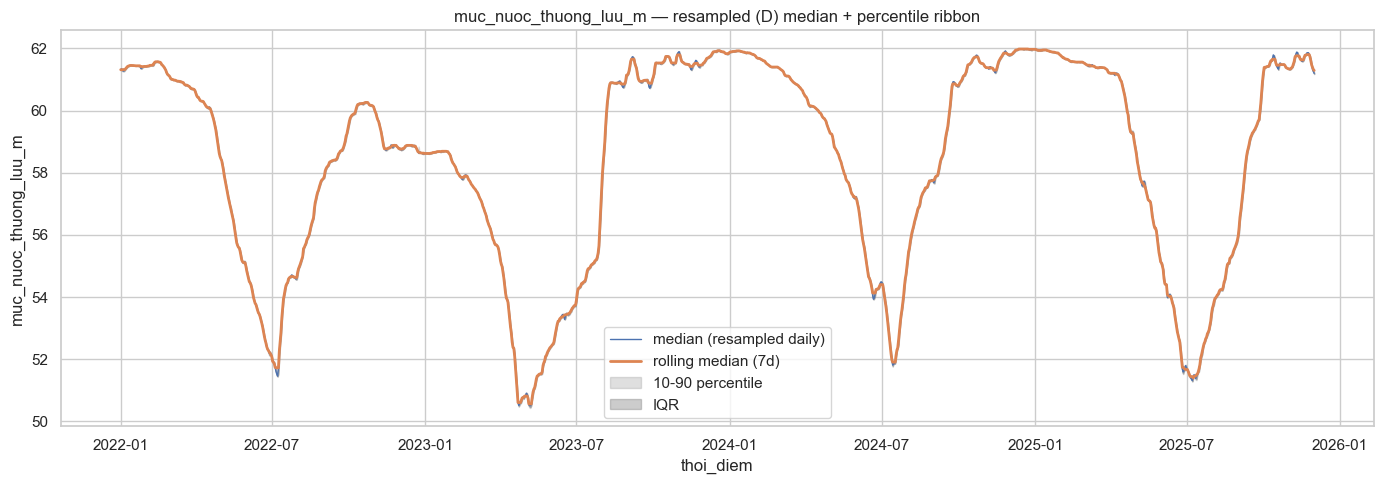

Saved: .././TrucQuanDonBien/TriAn\muc_nuoc_thuong_luu_m_resampled_trend_daily.png


In [26]:
# Cell 3 (bản sửa): Resampled trend + percentile ribbon theo NGÀY ('D')
# Cố định freq='D' để mỗi ngày gom ~8 điểm -> P10/P25/P75/P90 & IQR hiện rõ

# Bảo đảm cột thời gian ở dạng datetime và đã sort
df['thoi_diem'] = pd.to_datetime(df['thoi_diem'], errors='coerce')
df = df.sort_values('thoi_diem')

freq = 'D'  # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<  CHỈNH TẠI ĐÂY

series = (
    df.set_index('thoi_diem')[target]
      .resample(freq)
      .agg(['count', 'median', 'mean'])
)

# percentiles per resample (theo NGÀY)
agg_pct = (
    df.set_index('thoi_diem')[target]
      .resample(freq)
      .apply(lambda x: np.percentile(x.dropna(), [10, 25, 75, 90]) if len(x.dropna()) > 0 else [np.nan]*4)
)
pct_df = pd.DataFrame(agg_pct.tolist(), index=agg_pct.index, columns=['p10','p25','p75','p90'])

summary = pd.concat([series, pct_df], axis=1).dropna(subset=['median'])

# rolling median cho daily: 7 ngày
window = 7
summary['roll_median'] = summary['median'].rolling(window=window, min_periods=1, center=True).median()

plt.figure(figsize=(14,5))
plt.plot(summary.index, summary['median'], label='median (resampled daily)', linewidth=1)
plt.plot(summary.index, summary['roll_median'], label=f'rolling median ({window}d)', linewidth=2)
plt.fill_between(summary.index, summary['p10'], summary['p90'], color='grey', alpha=0.25, label='10-90 percentile')
plt.fill_between(summary.index, summary['p25'], summary['p75'], color='grey', alpha=0.40, label='IQR')
plt.legend()
plt.xlabel('thoi_diem'); plt.ylabel(target)
plt.title(f'{target} — resampled ({freq}) median + percentile ribbon')
plt.tight_layout()

# Lưu ảnh
if 'out_dir' not in globals():
    out_dir = ".././TrucQuanDaBien/TriAn"
import os
os.makedirs(out_dir, exist_ok=True)
fn = os.path.join(out_dir, f"{target}_resampled_trend_daily.png")
plt.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", fn)


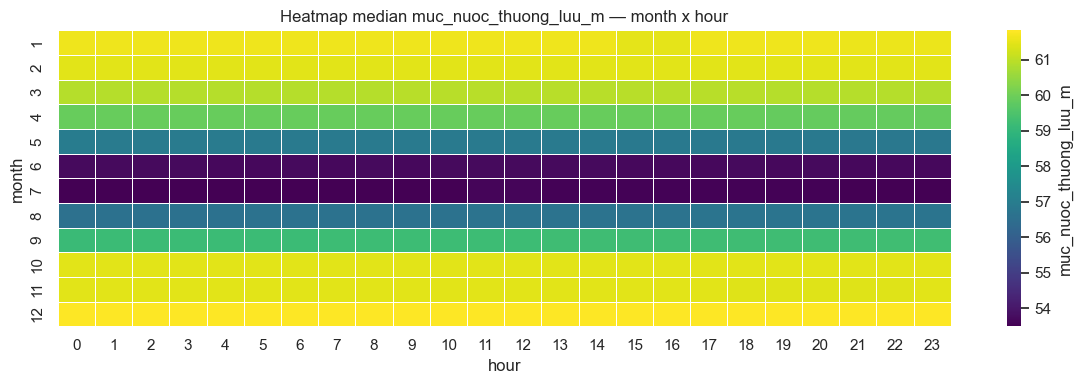

Saved: .././TrucQuanDonBien/TriAn\muc_nuoc_thuong_luu_m_month_hour_heatmap.png


In [27]:
# Cell 4: Heatmap month x hour (muốn pattern theo giờ trong năm) — gọn, dễ đọc (12x24)
df2 = df.dropna(subset=['thoi_diem', target]).copy()
df2['month'] = df2['thoi_diem'].dt.month
df2['hour'] = df2['thoi_diem'].dt.hour
pivot = df2.pivot_table(index='month', columns='hour', values=target, aggfunc='median')  # median robust
plt.figure(figsize=(12,4))
sns.heatmap(pivot, cmap='viridis', cbar_kws={'label': target}, linewidths=0.5)
plt.title(f'Heatmap median {target} — month x hour')
plt.ylabel('month'); plt.xlabel('hour')
plt.tight_layout()
fn = os.path.join(out_dir, f"{target}_month_hour_heatmap.png")
plt.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", fn)


muc_nuoc_thuong_luu_m IQR bounds: LB=47.14, UB=69.98
Full n=34,343 | Inlier n=34,334 | Outlier n=9


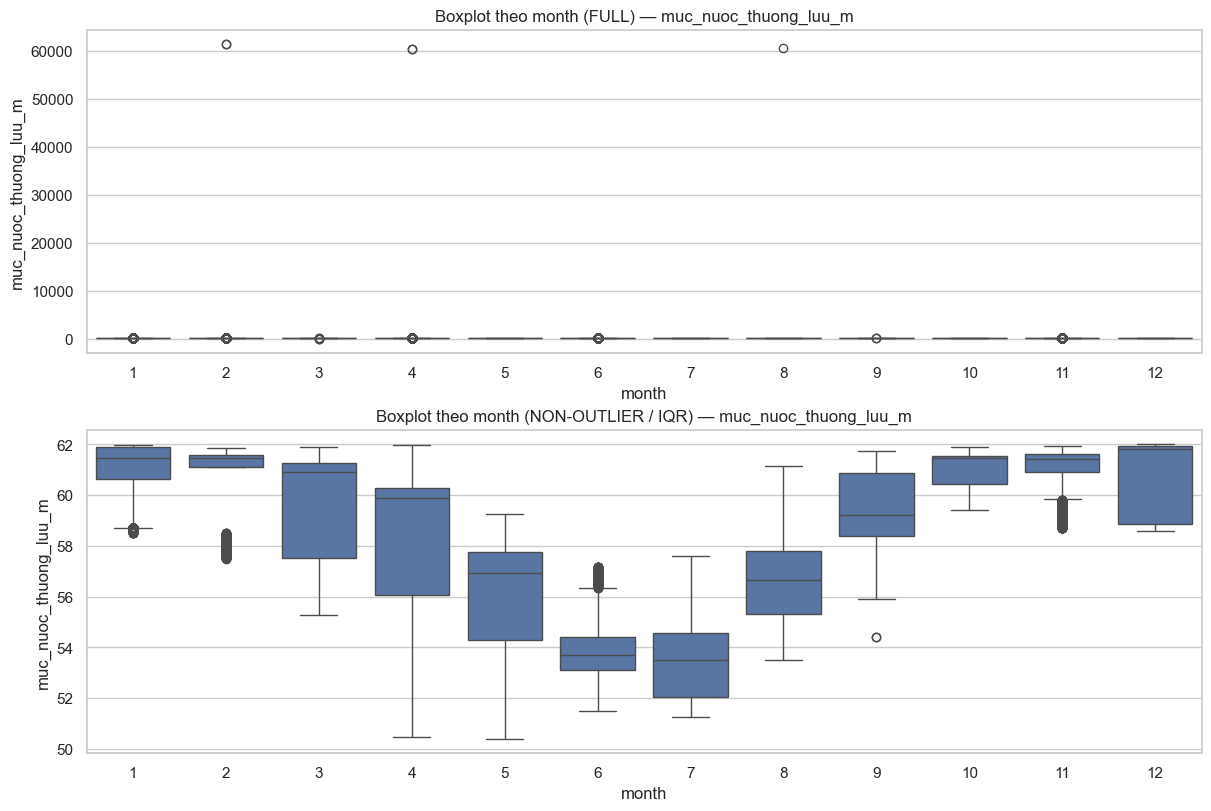

Saved: .././TrucQuanDonBien/TriAn\muc_nuoc_thuong_luu_m_box_month_full_vs_inlier.png


In [28]:
target = "muc_nuoc_thuong_luu_m"

df_b = df2.copy()  # df2 đã có month (và thường là đã parse datetime)
order_month = list(range(1, 13))

# --- Tính IQR bounds trên toàn bộ dữ liệu (global) ---
s = df_b[target].dropna().astype(float)
if s.empty:
    print(f"{target}: không có dữ liệu sau khi clean. Bỏ qua.")
else:
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    LB = Q1 - 1.5 * IQR
    UB = Q3 + 1.5 * IQR

    # --- Tạo df non-outlier ---
    df_inlier = df_b[df_b[target].astype(float).between(LB, UB)].copy()

    # Output folder
    out_dir = out_dir if 'out_dir' in globals() else ".././TrucQuanDonBien/SongBaHa"
    os.makedirs(out_dir, exist_ok=True)

    print(f"{target} IQR bounds: LB={LB:.2f}, UB={UB:.2f}")
    print(f"Full n={len(df_b):,} | Inlier n={len(df_inlier):,} | Outlier n={(len(df_b)-len(df_inlier)):,}")

    # --- Plot 2x1: FULL vs INLIER ---
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

    sns.boxplot(x='month', y=target, data=df_b, order=order_month, ax=axes[0])
    axes[0].set_title(f'Boxplot theo month (FULL) — {target}')
    axes[0].set_xlabel('month')

    sns.boxplot(x='month', y=target, data=df_inlier, order=order_month, ax=axes[1])
    axes[1].set_title(f'Boxplot theo month (NON-OUTLIER / IQR) — {target}')
    axes[1].set_xlabel('month')

    fn = os.path.join(out_dir, f"{target}_box_month_full_vs_inlier.png")
    fig.savefig(fn, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    print("Saved:", fn)

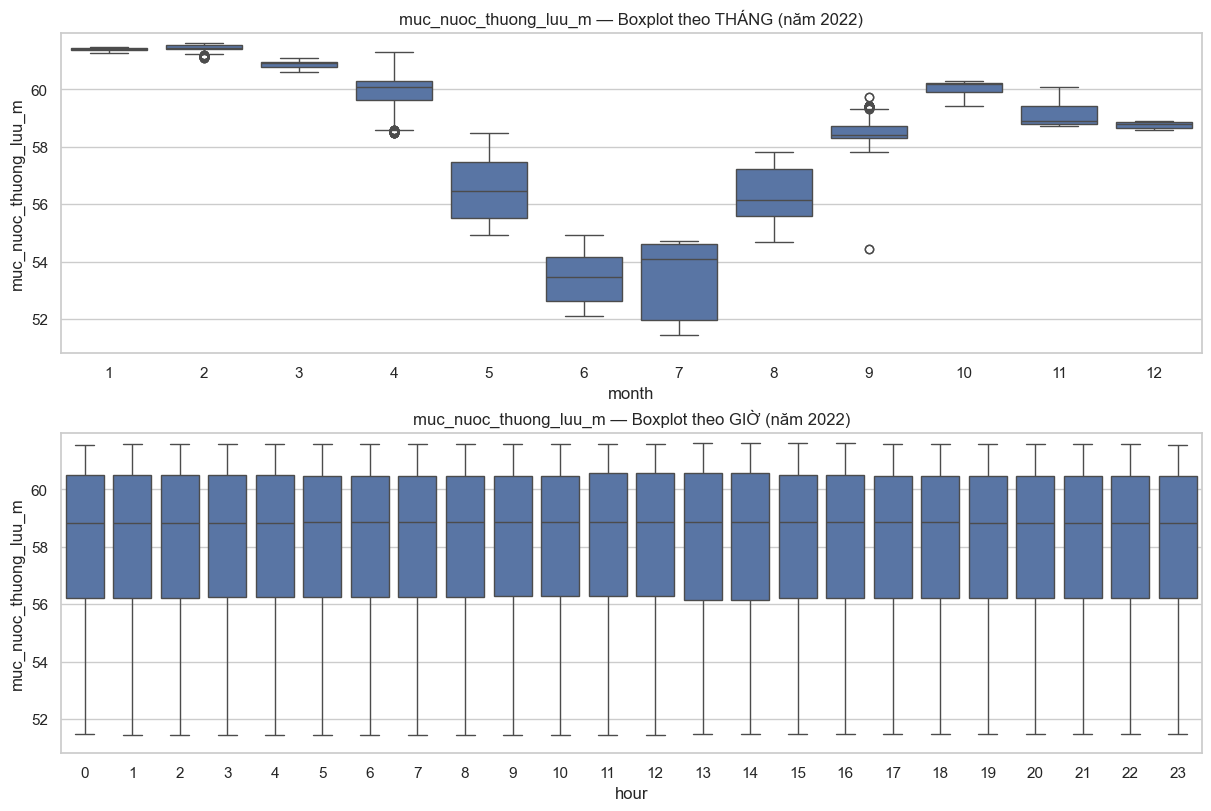

Saved: .././TrucQuanDonBien/TriAn\muc_nuoc_thuong_luu_m_box_month_hour_2022.png


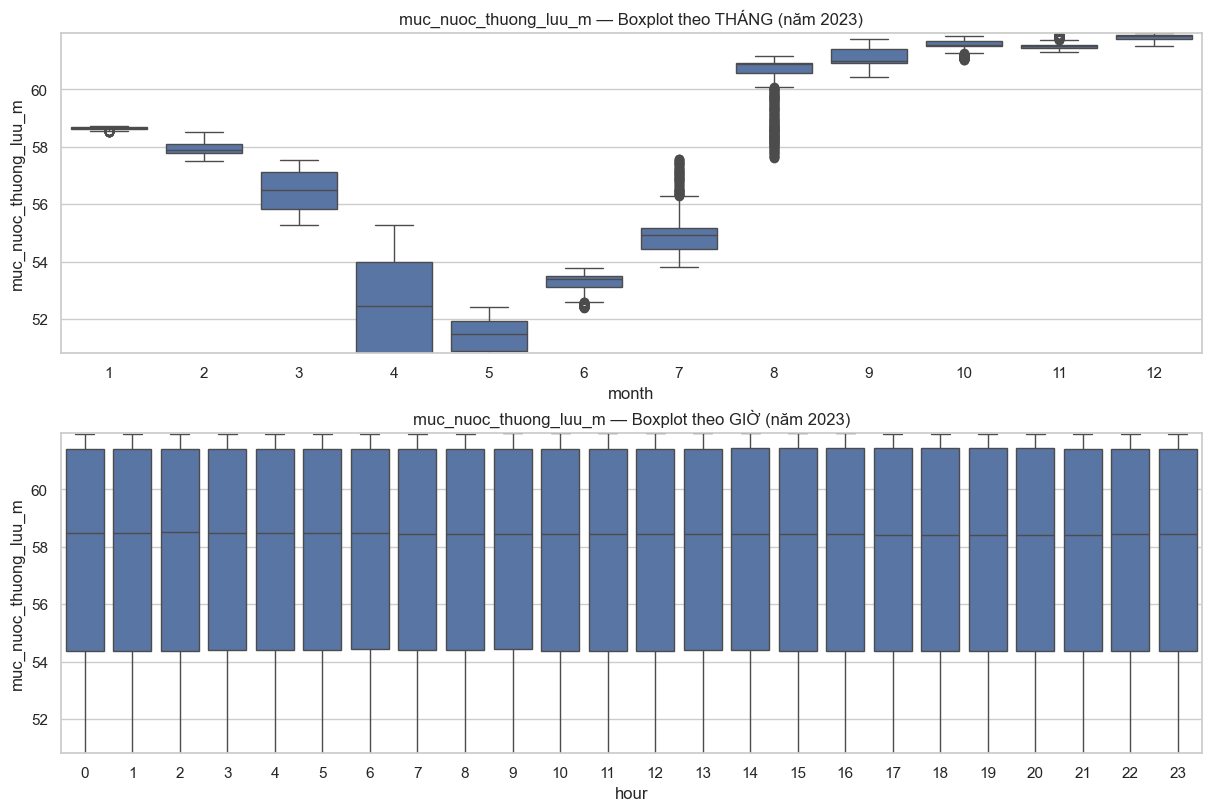

Saved: .././TrucQuanDonBien/TriAn\muc_nuoc_thuong_luu_m_box_month_hour_2023.png


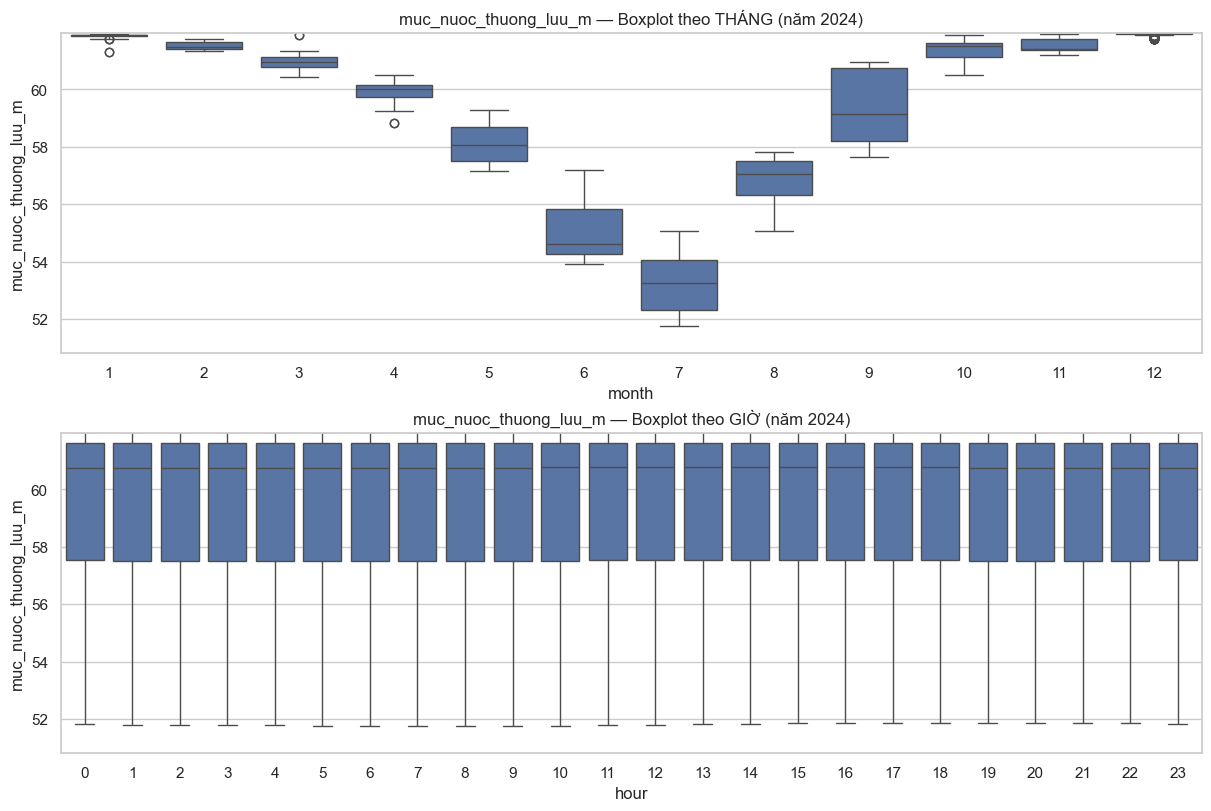

Saved: .././TrucQuanDonBien/TriAn\muc_nuoc_thuong_luu_m_box_month_hour_2024.png


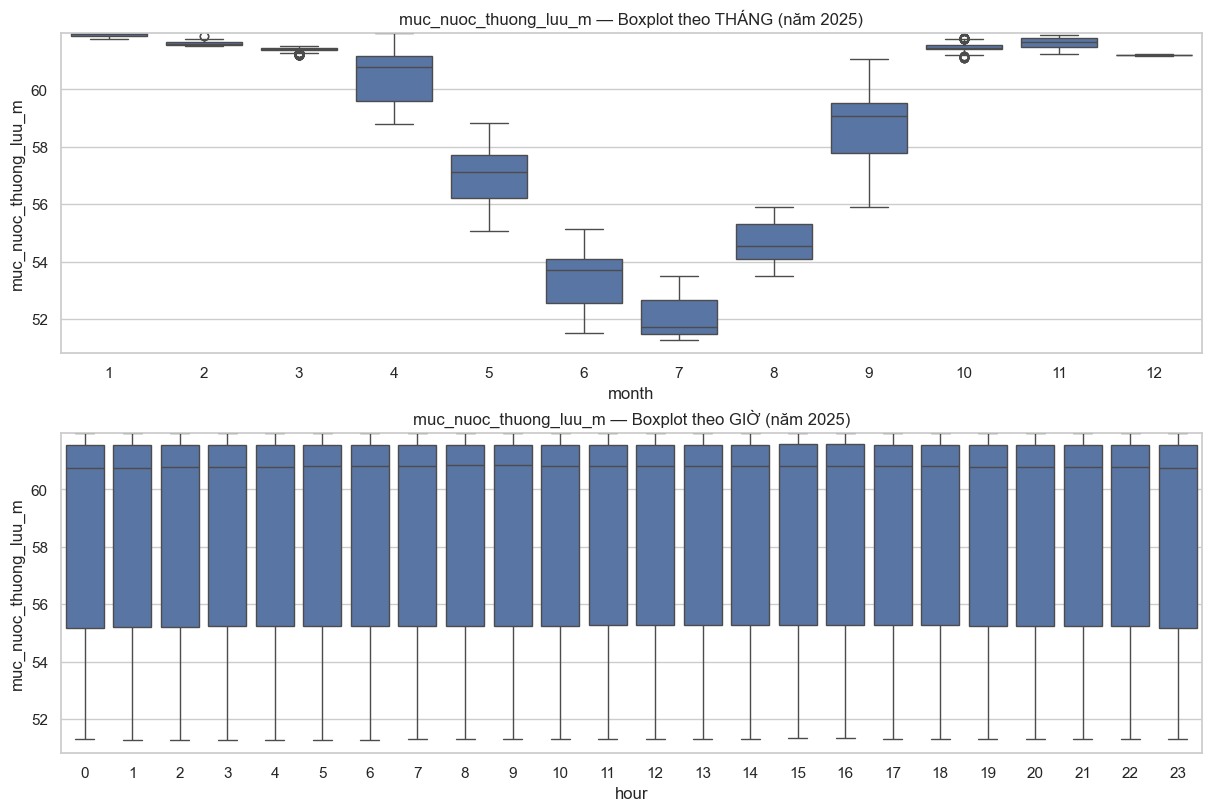

Saved: .././TrucQuanDonBien/TriAn\muc_nuoc_thuong_luu_m_box_month_hour_2025.png


In [29]:
# ==== Chuẩn bị ====
df_b = df2.copy()

# Bảo đảm có cột year/month/hour
if 'year' not in df_b:
    df_b['year'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.year
if 'month' not in df_b:
    df_b['month'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.month
if 'hour' not in df_b:
    df_b['hour'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.hour

order_month = list(range(1, 13))
order_hour = list(range(0, 24))

# Cố định trục Y để so sánh giữa các năm công bằng (dùng 1%–99% để tránh outlier cực đoan)
ymin = float(df_b[target].quantile(0.01))
ymax = float(df_b[target].quantile(0.99))
if not np.isfinite(ymin) or not np.isfinite(ymax) or ymin >= ymax:
    ymin = float(df_b[target].min())
    ymax = float(df_b[target].max())

# Thư mục xuất
if 'out_dir' not in globals():
    out_dir = "./data_thuydien/plots_thuydien"
os.makedirs(out_dir, exist_ok=True)

# ==== Vẽ vòng lặp theo năm ====
years = sorted([int(y) for y in df_b['year'].dropna().unique()])

for y in years:
    sub = df_b[df_b['year'] == y].copy()
    if sub.empty:
        continue

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

    # Boxplot theo tháng (năm y)
    sns.boxplot(x='month', y=target, data=sub, order=order_month, ax=axes[0])
    axes[0].set_title(f'{target} — Boxplot theo THÁNG (năm {y})')
    axes[0].set_xlabel('month'); axes[0].set_ylabel(target)
    axes[0].set_ylim(ymin, ymax)

    # Boxplot theo giờ (năm y)
    sns.boxplot(x='hour', y=target, data=sub, order=order_hour, ax=axes[1])
    axes[1].set_title(f'{target} — Boxplot theo GIỜ (năm {y})')
    axes[1].set_xlabel('hour'); axes[1].set_ylabel(target)
    axes[1].set_ylim(ymin, ymax)

    fn = os.path.join(out_dir, f"{target}_box_month_hour_{y}.png")
    fig.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
    print("Saved:", fn)


### Lưu lượng đến hồ (m3/s) trên từng thời điểm


In [30]:
df['thoi_diem'] = pd.to_datetime(df['thoi_diem'], errors='coerce')
df = df.sort_values('thoi_diem').reset_index(drop=True)
# chọn biến
target = 'luu_luong_den_ho_m3_s'
df[target] = pd.to_numeric(df[target].astype(str).str.replace(r'\s+','', regex=True).str.replace(',',''), errors='coerce')

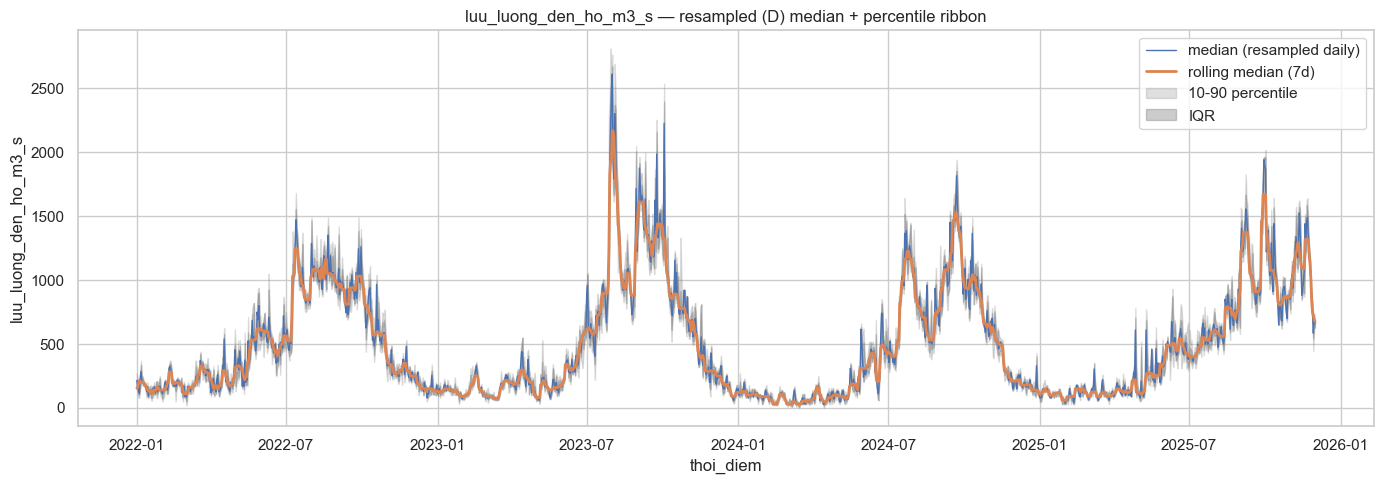

Saved: .././TrucQuanDonBien/TriAn\luu_luong_den_ho_m3_s_resampled_trend_daily.png


In [31]:
# Cell 3 (bản sửa): Resampled trend + percentile ribbon theo NGÀY ('D')
# Cố định freq='D' để mỗi ngày gom ~8 điểm -> P10/P25/P75/P90 & IQR hiện rõ

# Bảo đảm cột thời gian ở dạng datetime và đã sort
df['thoi_diem'] = pd.to_datetime(df['thoi_diem'], errors='coerce')
df = df.sort_values('thoi_diem')

freq = 'D'  # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<  CHỈNH TẠI ĐÂY

series = (
    df.set_index('thoi_diem')[target]
      .resample(freq)
      .agg(['count', 'median', 'mean'])
)

# percentiles per resample (theo NGÀY)
agg_pct = (
    df.set_index('thoi_diem')[target]
      .resample(freq)
      .apply(lambda x: np.percentile(x.dropna(), [10, 25, 75, 90]) if len(x.dropna()) > 0 else [np.nan]*4)
)
pct_df = pd.DataFrame(agg_pct.tolist(), index=agg_pct.index, columns=['p10','p25','p75','p90'])

summary = pd.concat([series, pct_df], axis=1).dropna(subset=['median'])

# rolling median cho daily: 7 ngày
window = 7
summary['roll_median'] = summary['median'].rolling(window=window, min_periods=1, center=True).median()

plt.figure(figsize=(14,5))
plt.plot(summary.index, summary['median'], label='median (resampled daily)', linewidth=1)
plt.plot(summary.index, summary['roll_median'], label=f'rolling median ({window}d)', linewidth=2)
plt.fill_between(summary.index, summary['p10'], summary['p90'], color='grey', alpha=0.25, label='10-90 percentile')
plt.fill_between(summary.index, summary['p25'], summary['p75'], color='grey', alpha=0.40, label='IQR')
plt.legend()
plt.xlabel('thoi_diem'); plt.ylabel(target)
plt.title(f'{target} — resampled ({freq}) median + percentile ribbon')
plt.tight_layout()

# Lưu ảnh
if 'out_dir' not in globals():
    out_dir = ".././TrucQuanDaBien/TriAn"
import os
os.makedirs(out_dir, exist_ok=True)
fn = os.path.join(out_dir, f"{target}_resampled_trend_daily.png")
plt.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", fn)


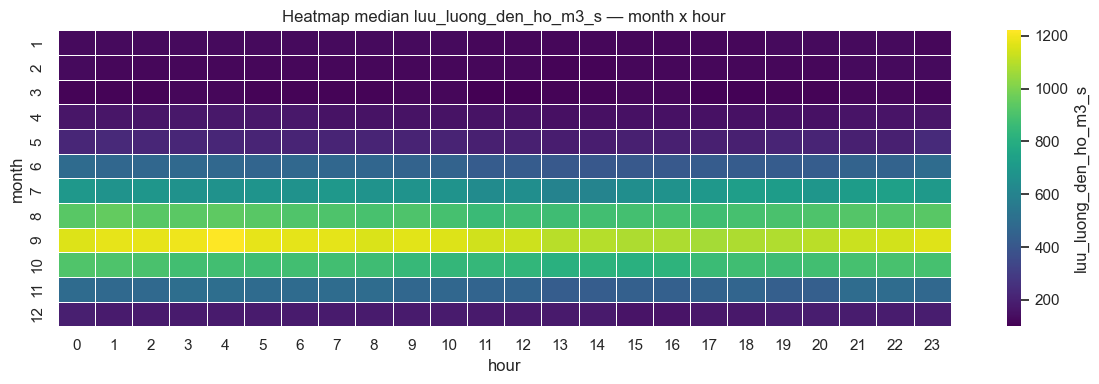

Saved: .././TrucQuanDonBien/TriAn\luu_luong_den_ho_m3_s_month_hour_heatmap.png


In [32]:
# Cell 4: Heatmap month x hour (muốn pattern theo giờ trong năm) — gọn, dễ đọc (12x24)
df2 = df.dropna(subset=['thoi_diem', target]).copy()
df2['month'] = df2['thoi_diem'].dt.month
df2['hour'] = df2['thoi_diem'].dt.hour
pivot = df2.pivot_table(index='month', columns='hour', values=target, aggfunc='median')  # median robust
plt.figure(figsize=(12,4))
sns.heatmap(pivot, cmap='viridis', cbar_kws={'label': target}, linewidths=0.5)
plt.title(f'Heatmap median {target} — month x hour')
plt.ylabel('month'); plt.xlabel('hour')
plt.tight_layout()
fn = os.path.join(out_dir, f"{target}_month_hour_heatmap.png")
plt.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", fn)


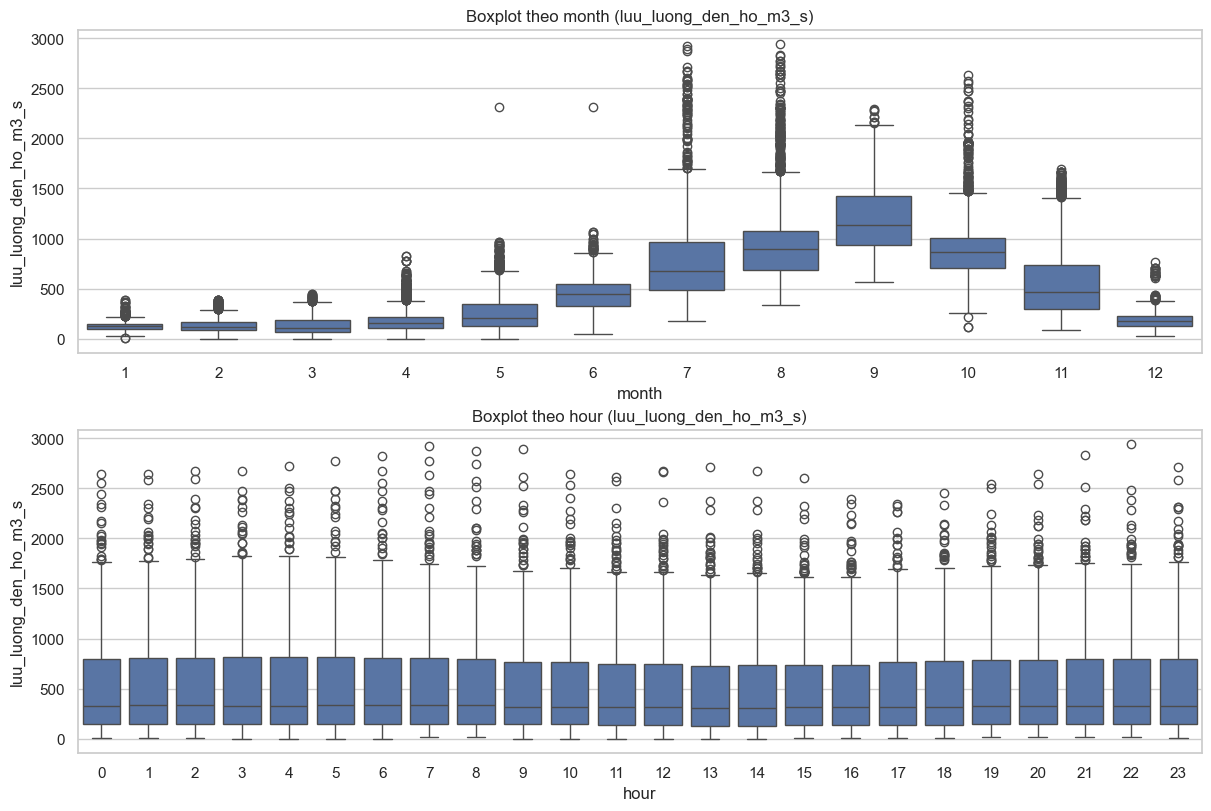

Saved: .././TrucQuanDonBien/TriAn\luu_luong_den_ho_m3_s_box_month_hour.png


In [33]:
# Cell 5: Boxplot by month (12 boxes) + Boxplot by hour (24 boxes) — 2x1 matrix, đơn giản, tổng quát
df_b = df2.copy()
order_month = list(range(1,13))
order_hour = list(range(0,24))

fig, axes = plt.subplots(2,1, figsize=(12,8), constrained_layout=True)
sns.boxplot(x='month', y=target, data=df_b, order=order_month, ax=axes[0])
axes[0].set_title(f'Boxplot theo month ({target})'); axes[0].set_xlabel('month')

sns.boxplot(x='hour', y=target, data=df_b, order=order_hour, ax=axes[1])
axes[1].set_title(f'Boxplot theo hour ({target})'); axes[1].set_xlabel('hour')

fn = os.path.join(out_dir, f"{target}_box_month_hour.png")
fig.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", fn)


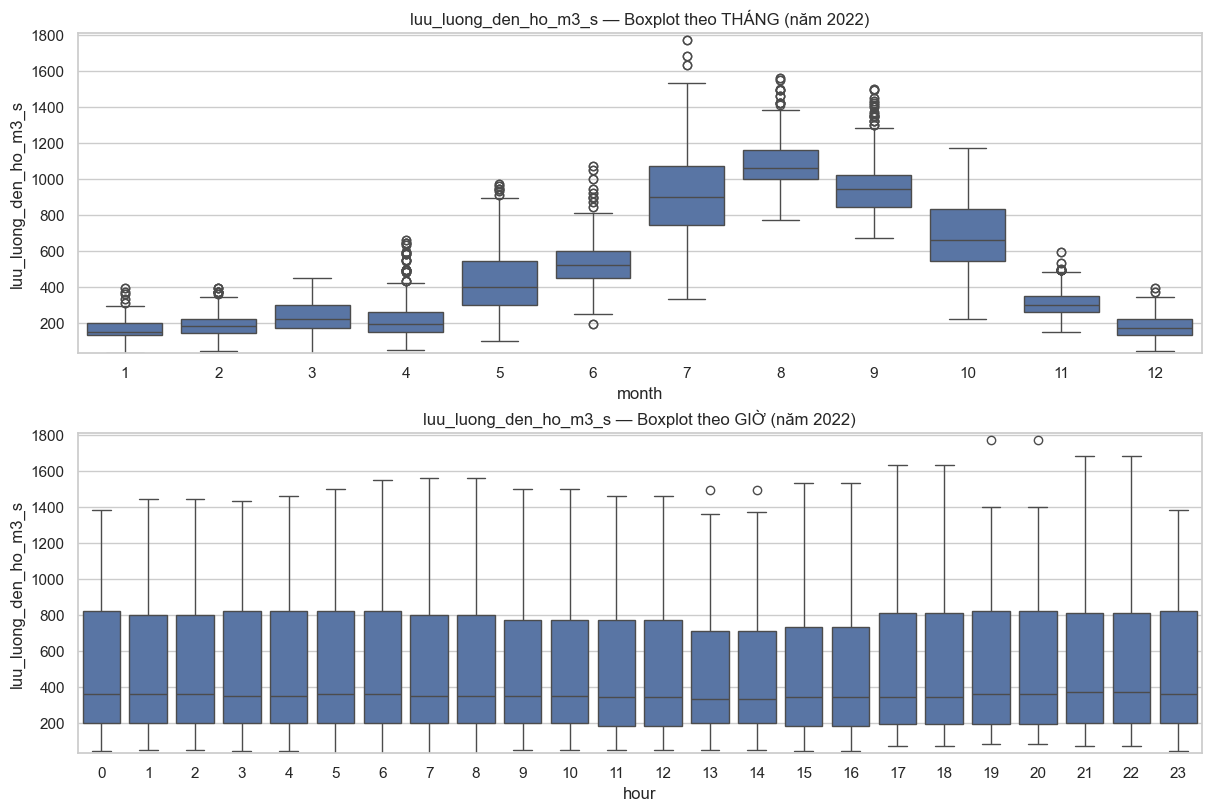

Saved: .././TrucQuanDonBien/TriAn\luu_luong_den_ho_m3_s_box_month_hour_2022.png


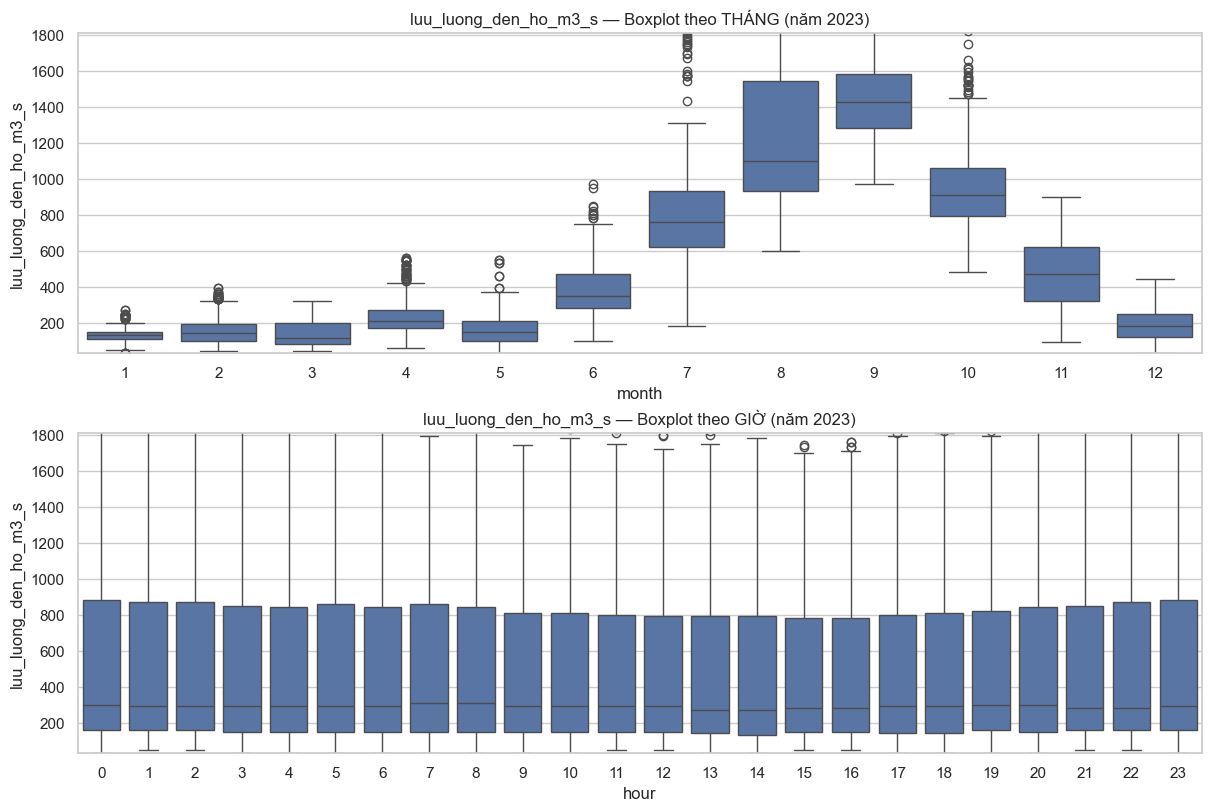

Saved: .././TrucQuanDonBien/TriAn\luu_luong_den_ho_m3_s_box_month_hour_2023.png


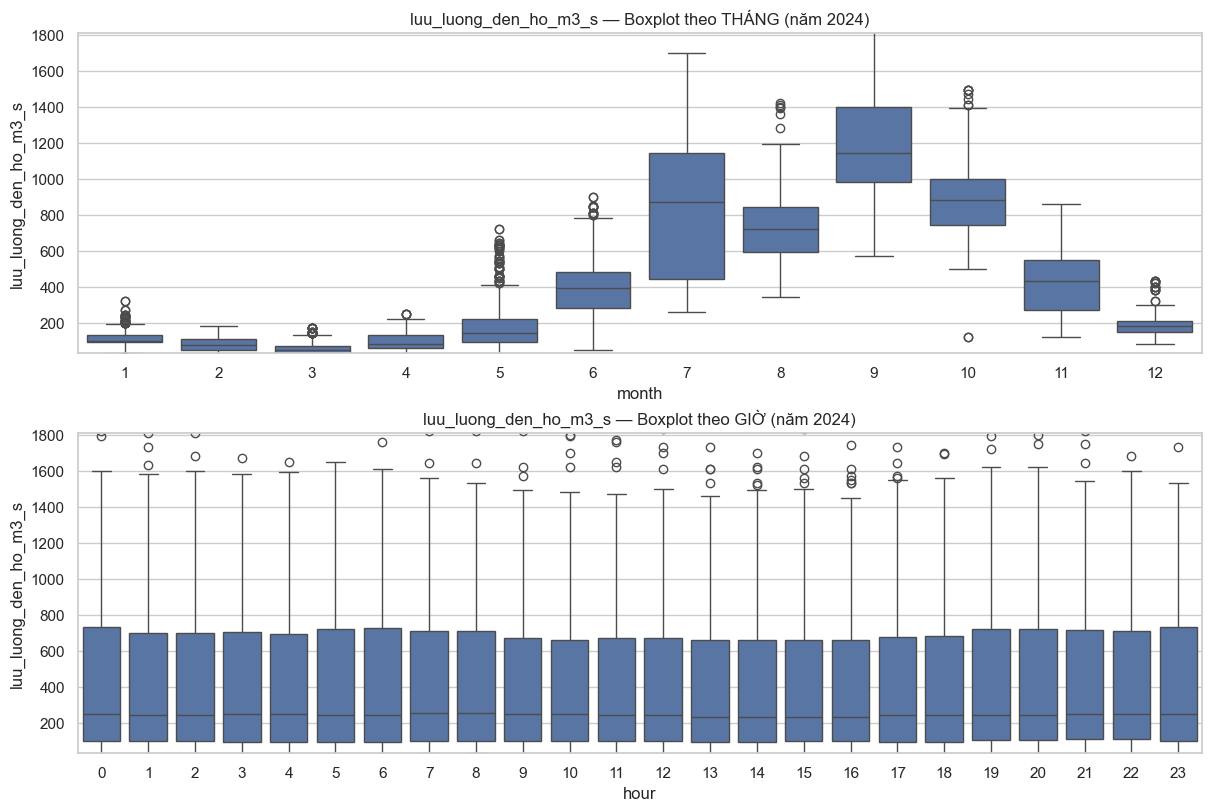

Saved: .././TrucQuanDonBien/TriAn\luu_luong_den_ho_m3_s_box_month_hour_2024.png


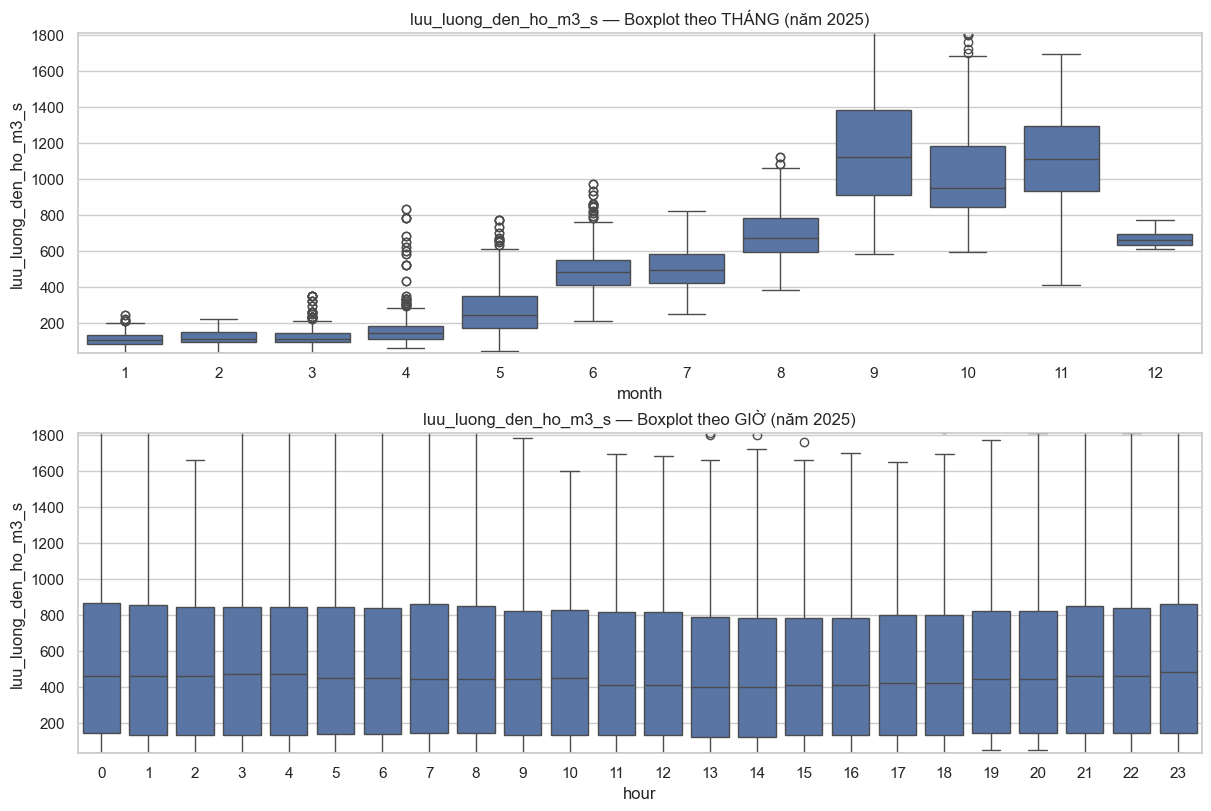

Saved: .././TrucQuanDonBien/TriAn\luu_luong_den_ho_m3_s_box_month_hour_2025.png


In [34]:
# ==== Chuẩn bị ====
df_b = df2.copy()

# Bảo đảm có cột year/month/hour
if 'year' not in df_b:
    df_b['year'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.year
if 'month' not in df_b:
    df_b['month'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.month
if 'hour' not in df_b:
    df_b['hour'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.hour

order_month = list(range(1, 13))
order_hour = list(range(0, 24))

# Cố định trục Y để so sánh giữa các năm công bằng (dùng 1%–99% để tránh outlier cực đoan)
ymin = float(df_b[target].quantile(0.01))
ymax = float(df_b[target].quantile(0.99))
if not np.isfinite(ymin) or not np.isfinite(ymax) or ymin >= ymax:
    ymin = float(df_b[target].min())
    ymax = float(df_b[target].max())

# Thư mục xuất
if 'out_dir' not in globals():
    out_dir = "./data_thuydien/plots_thuydien"
os.makedirs(out_dir, exist_ok=True)

# ==== Vẽ vòng lặp theo năm ====
years = sorted([int(y) for y in df_b['year'].dropna().unique()])

for y in years:
    sub = df_b[df_b['year'] == y].copy()
    if sub.empty:
        continue

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

    # Boxplot theo tháng (năm y)
    sns.boxplot(x='month', y=target, data=sub, order=order_month, ax=axes[0])
    axes[0].set_title(f'{target} — Boxplot theo THÁNG (năm {y})')
    axes[0].set_xlabel('month'); axes[0].set_ylabel(target)
    axes[0].set_ylim(ymin, ymax)

    # Boxplot theo giờ (năm y)
    sns.boxplot(x='hour', y=target, data=sub, order=order_hour, ax=axes[1])
    axes[1].set_title(f'{target} — Boxplot theo GIỜ (năm {y})')
    axes[1].set_xlabel('hour'); axes[1].set_ylabel(target)
    axes[1].set_ylim(ymin, ymax)

    fn = os.path.join(out_dir, f"{target}_box_month_hour_{y}.png")
    fig.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
    print("Saved:", fn)

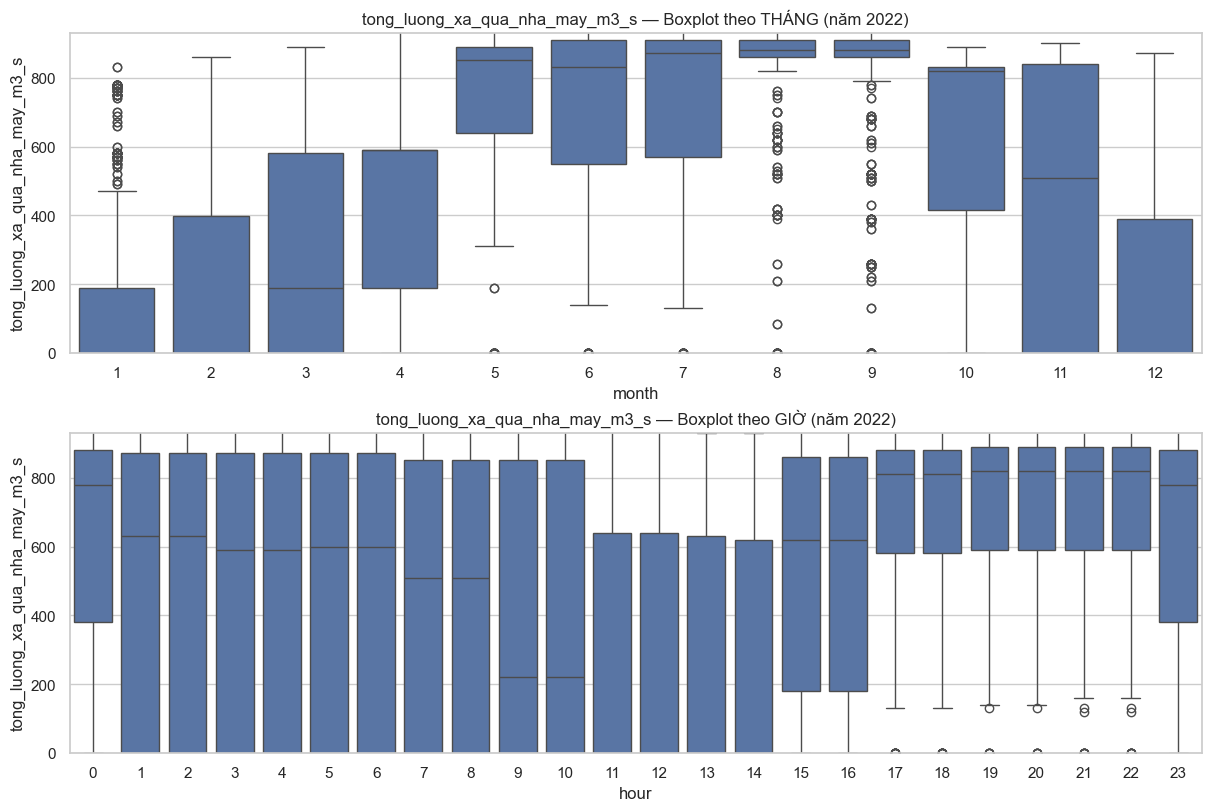

Saved: .././TrucQuanDonBien/TriAn\tong_luong_xa_qua_nha_may_m3_s_box_month_hour_2022.png


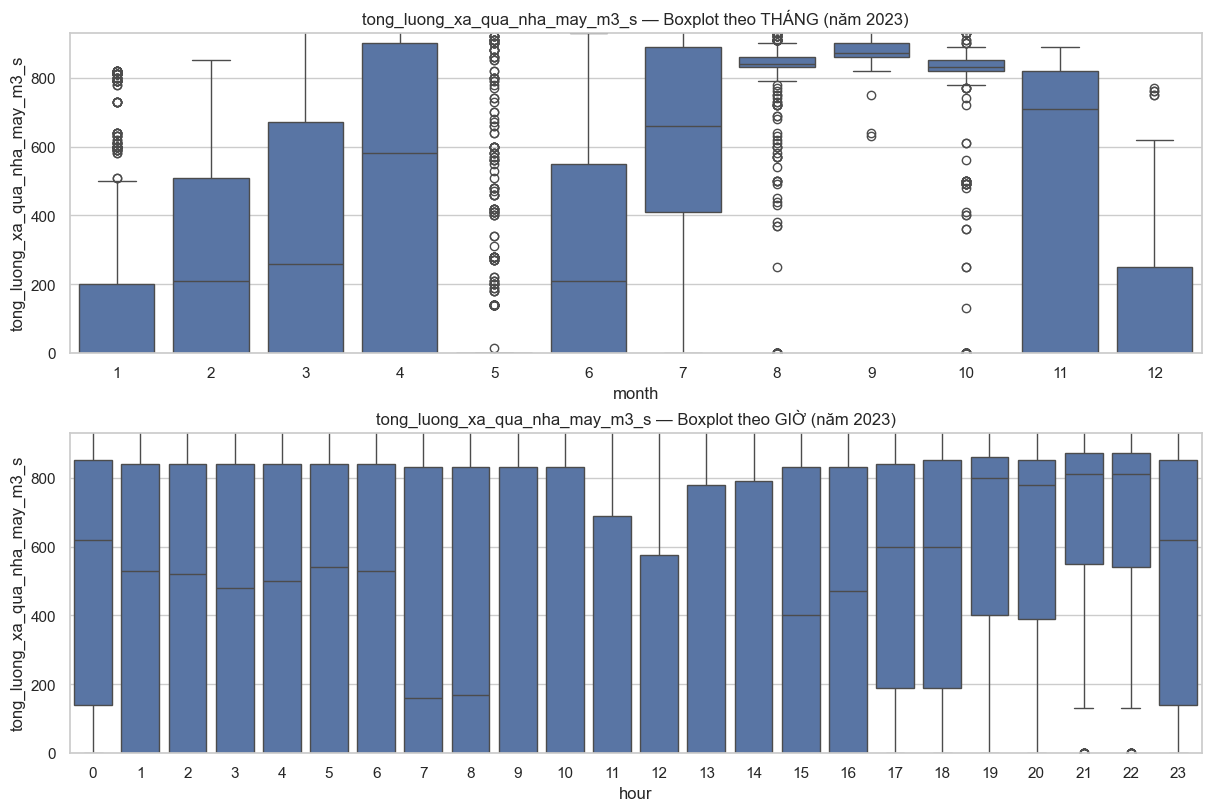

Saved: .././TrucQuanDonBien/TriAn\tong_luong_xa_qua_nha_may_m3_s_box_month_hour_2023.png


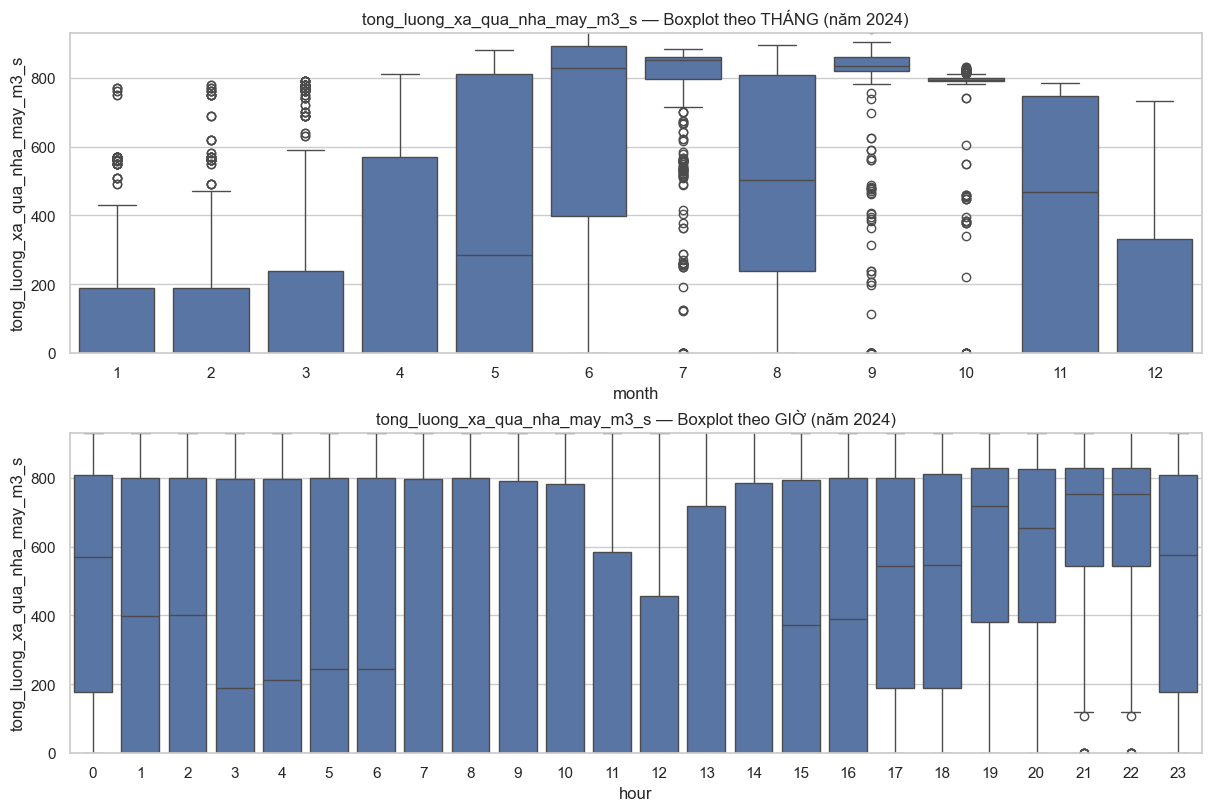

Saved: .././TrucQuanDonBien/TriAn\tong_luong_xa_qua_nha_may_m3_s_box_month_hour_2024.png


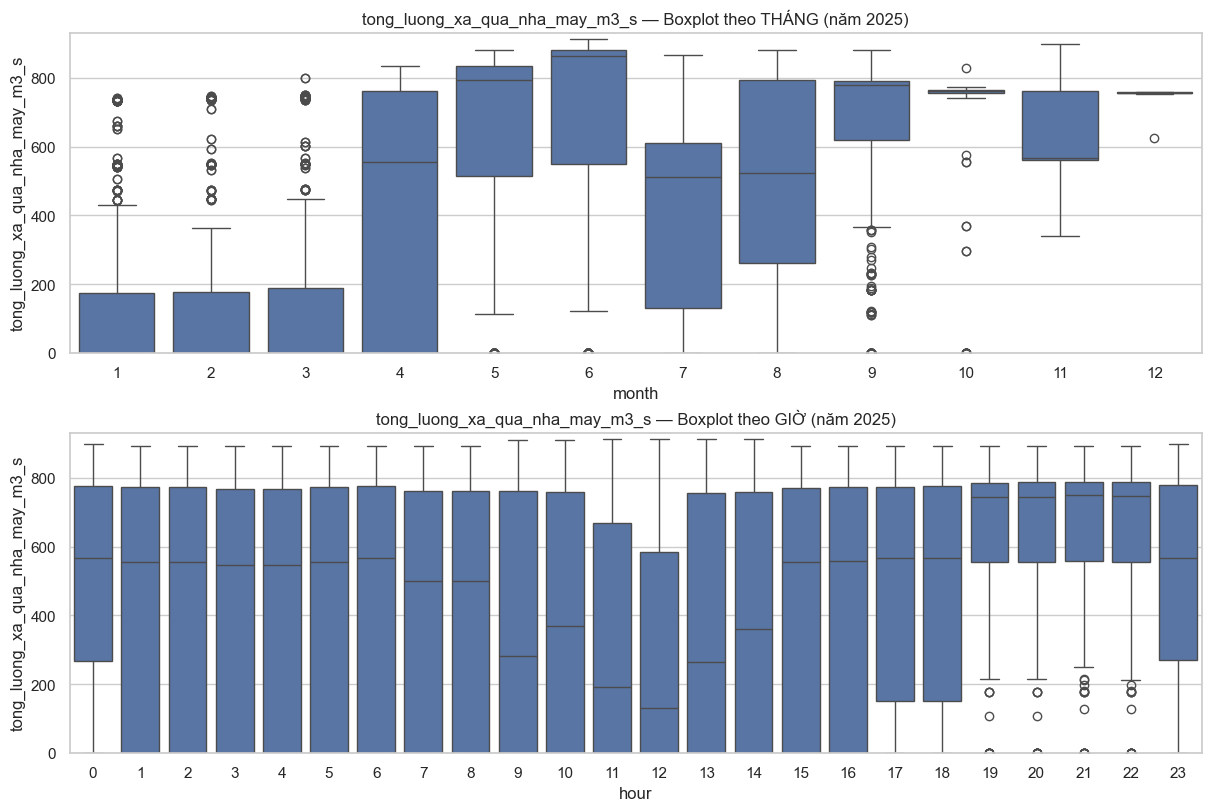

Saved: .././TrucQuanDonBien/TriAn\tong_luong_xa_qua_nha_may_m3_s_box_month_hour_2025.png


In [35]:
target='tong_luong_xa_qua_nha_may_m3_s'
# ==== Chuẩn bị ====
df_b = df2.copy()

# Bảo đảm có cột year/month/hour
if 'year' not in df_b:
    df_b['year'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.year
if 'month' not in df_b:
    df_b['month'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.month
if 'hour' not in df_b:
    df_b['hour'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.hour

order_month = list(range(1, 13))
order_hour = list(range(0, 24))

# Cố định trục Y để so sánh giữa các năm công bằng (dùng 1%–99% để tránh outlier cực đoan)
ymin = float(df_b[target].quantile(0.01))
ymax = float(df_b[target].quantile(0.99))
if not np.isfinite(ymin) or not np.isfinite(ymax) or ymin >= ymax:
    ymin = float(df_b[target].min())
    ymax = float(df_b[target].max())

# Thư mục xuất
if 'out_dir' not in globals():
    out_dir = "./data_thuydien/plots_thuydien"
os.makedirs(out_dir, exist_ok=True)

# ==== Vẽ vòng lặp theo năm ====
years = sorted([int(y) for y in df_b['year'].dropna().unique()])

for y in years:
    sub = df_b[df_b['year'] == y].copy()
    if sub.empty:
        continue

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

    # Boxplot theo tháng (năm y)
    sns.boxplot(x='month', y=target, data=sub, order=order_month, ax=axes[0])
    axes[0].set_title(f'{target} — Boxplot theo THÁNG (năm {y})')
    axes[0].set_xlabel('month'); axes[0].set_ylabel(target)
    axes[0].set_ylim(ymin, ymax)

    # Boxplot theo giờ (năm y)
    sns.boxplot(x='hour', y=target, data=sub, order=order_hour, ax=axes[1])
    axes[1].set_title(f'{target} — Boxplot theo GIỜ (năm {y})')
    axes[1].set_xlabel('hour'); axes[1].set_ylabel(target)
    axes[1].set_ylim(ymin, ymax)

    fn = os.path.join(out_dir, f"{target}_box_month_hour_{y}.png")
    fig.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
    print("Saved:", fn)


tong_luong_xa_qua_dap_tran_m3_s

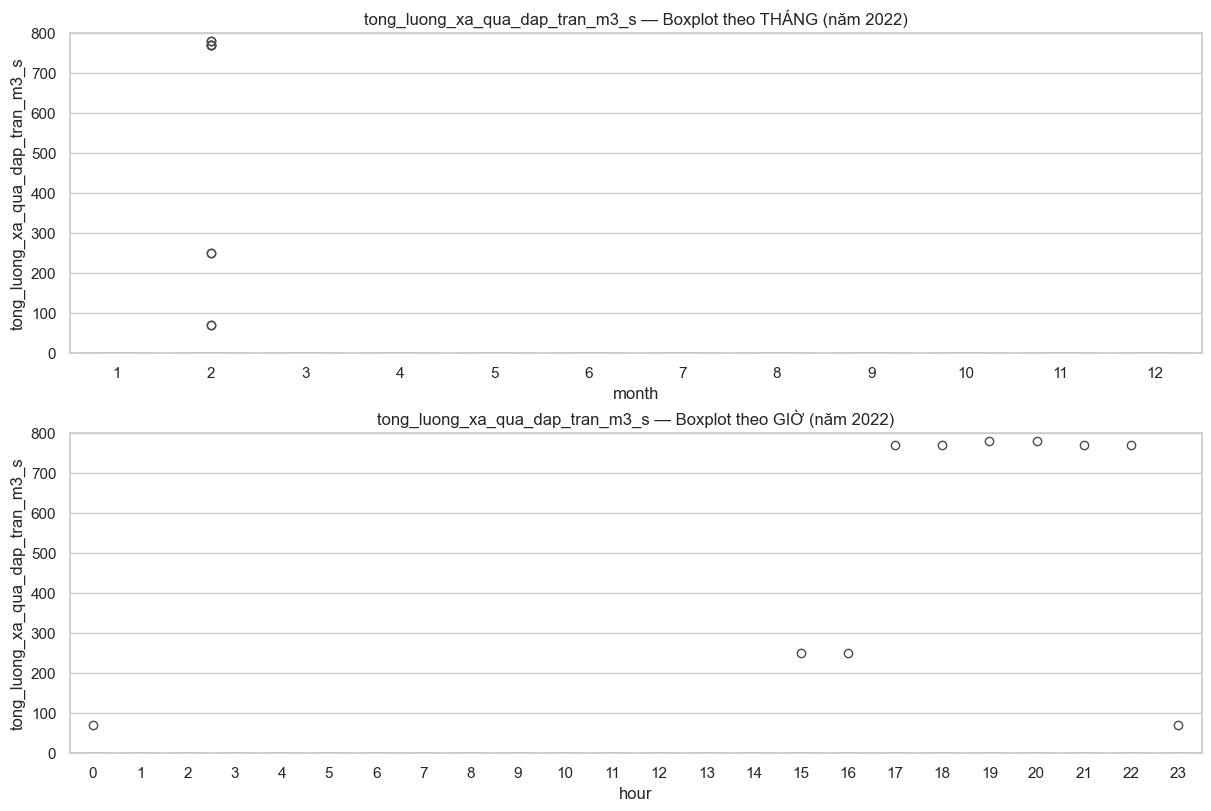

Saved: .././TrucQuanDonBien/TriAn\tong_luong_xa_qua_dap_tran_m3_s_box_month_hour_2022.png


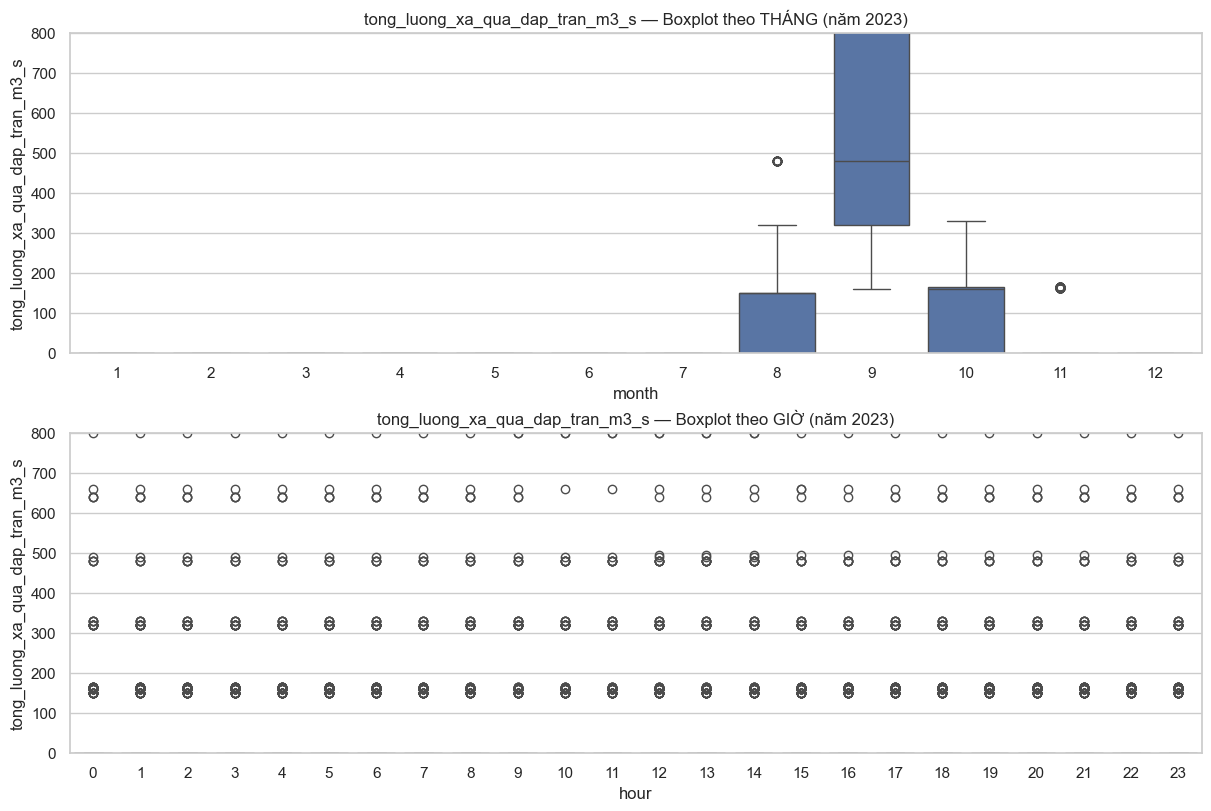

Saved: .././TrucQuanDonBien/TriAn\tong_luong_xa_qua_dap_tran_m3_s_box_month_hour_2023.png


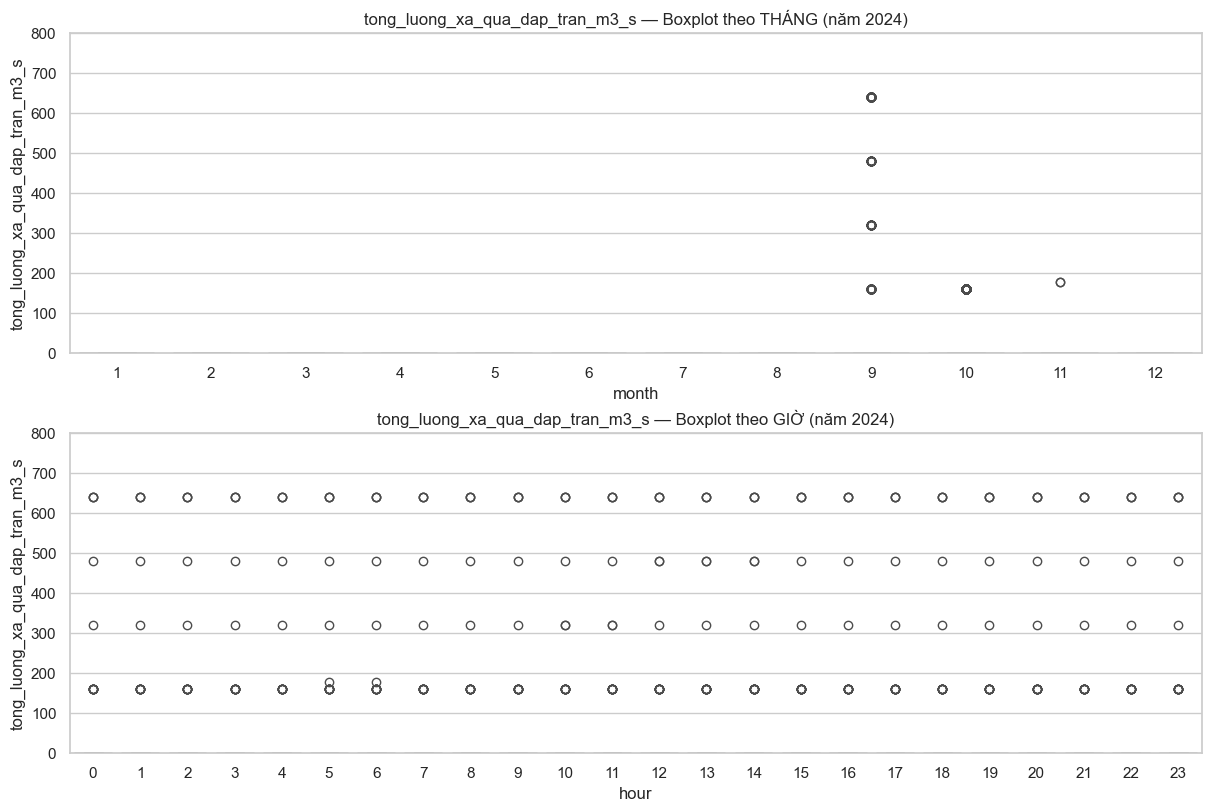

Saved: .././TrucQuanDonBien/TriAn\tong_luong_xa_qua_dap_tran_m3_s_box_month_hour_2024.png


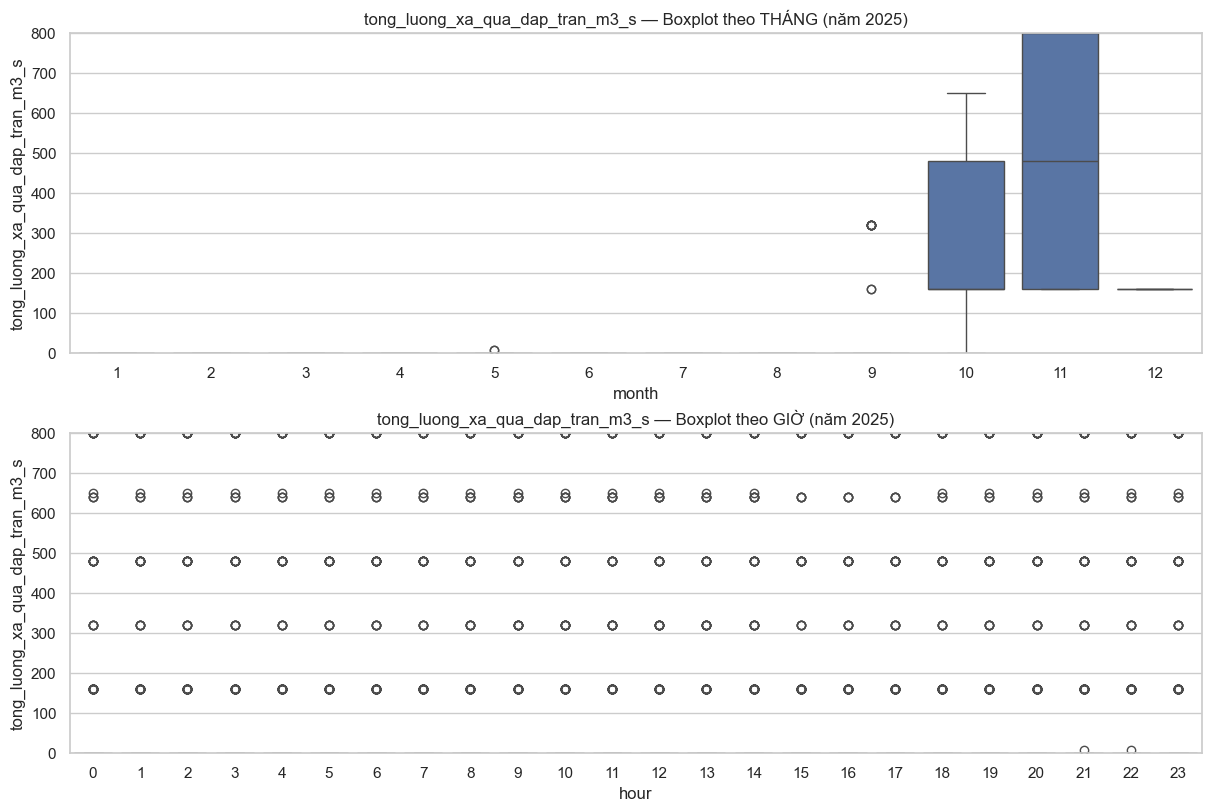

Saved: .././TrucQuanDonBien/TriAn\tong_luong_xa_qua_dap_tran_m3_s_box_month_hour_2025.png


In [36]:
target='tong_luong_xa_qua_dap_tran_m3_s'
# ==== Chuẩn bị ====
df_b = df2.copy()

# Bảo đảm có cột year/month/hour
if 'year' not in df_b:
    df_b['year'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.year
if 'month' not in df_b:
    df_b['month'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.month
if 'hour' not in df_b:
    df_b['hour'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.hour

order_month = list(range(1, 13))
order_hour = list(range(0, 24))

# Cố định trục Y để so sánh giữa các năm công bằng (dùng 1%–99% để tránh outlier cực đoan)
ymin = float(df_b[target].quantile(0.01))
ymax = float(df_b[target].quantile(0.99))
if not np.isfinite(ymin) or not np.isfinite(ymax) or ymin >= ymax:
    ymin = float(df_b[target].min())
    ymax = float(df_b[target].max())

# Thư mục xuất
if 'out_dir' not in globals():
    out_dir = "./data_thuydien/plots_thuydien"
os.makedirs(out_dir, exist_ok=True)

# ==== Vẽ vòng lặp theo năm ====
years = sorted([int(y) for y in df_b['year'].dropna().unique()])

for y in years:
    sub = df_b[df_b['year'] == y].copy()
    if sub.empty:
        continue

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

    # Boxplot theo tháng (năm y)
    sns.boxplot(x='month', y=target, data=sub, order=order_month, ax=axes[0])
    axes[0].set_title(f'{target} — Boxplot theo THÁNG (năm {y})')
    axes[0].set_xlabel('month'); axes[0].set_ylabel(target)
    axes[0].set_ylim(ymin, ymax)

    # Boxplot theo giờ (năm y)
    sns.boxplot(x='hour', y=target, data=sub, order=order_hour, ax=axes[1])
    axes[1].set_title(f'{target} — Boxplot theo GIỜ (năm {y})')
    axes[1].set_xlabel('hour'); axes[1].set_ylabel(target)
    axes[1].set_ylim(ymin, ymax)

    fn = os.path.join(out_dir, f"{target}_box_month_hour_{y}.png")
    fig.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
    print("Saved:", fn)
